### 1) Install Dependencies
This cell installs the core libraries used throughout the notebook, including PPO (Stable-Baselines3), Gymnasium, and plotting/numerical tools.

In [8]:
!pip install stable-baselines3 gymnasium matplotlib numpy

### 2) Define Experiment Configuration
This cell loads the JSON configuration into `CFG`, including herd composition, environment physics, training hyperparameters, and evaluation settings.

In [9]:
import json

config_str = """
{
  "herd": {
    "counts": {"piglets": 0, "young": 0, "adults": 8},
    "comfort_zones": {
      "piglets": [28, 34],
      "young":   [18, 26],
      "adults":  [15, 22],
      "source":  "default"
    }
  },
  "training": {
    "sensors": {"humidity": true, "co2": true, "clock": true},
    "equipment": {"heaters": 2, "fans": 2, "sprinklers": 1},
    "total_timesteps": 2000000,
    "learning_rate": 0.0003,
    "n_steps": 4096,
    "batch_size": 128,
    "ent_coef": 0.05,
    "device": "cuda",
    "save_path": "ppo_swine_v2",
    "stats_path": "swine_vec_normalize_v2.pkl"
  },
  "eval": {
    "sensors": {"humidity": false, "co2": false, "clock": true},
    "equipment": {"heaters": 2, "fans": 2, "sprinklers": 1}
  },
  "physics": {
    "heater_rate": 1.5,
    "fan_rate": 2.0,
    "sprinkler_cooling": 2.5,
    "bio_latency": 0.08,
    "ambient_drift_rate": 0.02,
    "noise_std": 0.05,
    "metabolic_heat": {"piglets": 0.05, "young": 0.15, "adults": 0.30},
    "sick_metabolic_multiplier": 1.25,
    "sick_event_probability": 0.30
  },
  "environment": {"temp_min": 0, "temp_max": 50, "max_steps": 1000}
}
"""

CFG = json.loads(config_str)

### 3) Train the Base RL Controller
This cell defines the custom swine environment, reward shaping, vectorized training setup, and then trains/saves the baseline PPO model and normalization statistics.

In [3]:
"""
SwineRL v2 — Training Script
==============================
Always trains with ALL sensors + equipment enabled (max obs dimensions).
Availability flags in the observation teach the model to ignore
zeroed-out inputs — so at eval time, missing sensors just get
masked to 0 and the same model still works.

Observation vector (always fixed size = 19):
  [0]     air_temp
  [1]     perceived_temp
  [2]     delta (air - perceived)
  [3-4]   heater states (2)
  [5-6]   fan states (2)
  [7]     sprinkler state
  [8-10]  herd counts (piglets, young, adults)
  [11]    humidity value (normalised 0-1)
  [12]    humidity_available flag (0 or 1)
  [13]    co2 value (normalised 0-1)
  [14]    co2_available flag (0 or 1)
  [15]    clock sin
  [16]    clock cos
  [17]    clock_available flag (0 or 1)

Action vector (always fixed size = 5):
  [0] heater1, [1] heater2, [2] fan1, [3] fan2, [4] sprinkler

Key design decisions:
  - total_stress REMOVED from obs (was causing 25C anchor)
  - Reward = only thermal_stress (agent only penalised for what it can control)
  - Sick events fire randomly but do NOT affect reward
  - Sprinkler penalised when humidity already high
  - Reset biases 50% of episodes toward herd's comfort zone
  - Parallel envs (8x) for faster training
"""

import os
import json
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.callbacks import BaseCallback

# ─────────────────────────────────────────────
# 1. LOAD CONFIG
# ─────────────────────────────────────────────
# CONFIG_PATH = "/kaggle/input/datasets/jheelgala/config-1/config.json"
# with open(CONFIG_PATH, "r") as f:
#     CFG = json.load(f)

HERD_CFG    = CFG["herd"]
TRAIN_CFG   = CFG["training"]
PHYSICS_CFG = CFG["physics"]
ENV_CFG     = CFG["environment"]

COMFORT = {
    0: HERD_CFG["comfort_zones"]["piglets"],
    1: HERD_CFG["comfort_zones"]["young"],
    2: HERD_CFG["comfort_zones"]["adults"],
}

def build_herd(counts):
    return (
        [0] * counts["piglets"] +
        [1] * counts["young"]   +
        [2] * counts["adults"]
    )

FIXED_HERD  = build_herd(HERD_CFG["counts"])
TOTAL_PIGS  = len(FIXED_HERD)

# Fixed obs and action dims — always max size regardless of config
OBS_DIM     = 18   # see header docstring
ACTION_NVEC = [2, 2, 2, 2, 2]   # heater1, heater2, fan1, fan2, sprinkler

print(f"Herd composition : {HERD_CFG['counts']}")
print(f"Observation dim  : {OBS_DIM}  (fixed, always max)")
print(f"Action space     : MultiDiscrete({ACTION_NVEC})")
print(f"Comfort zones    : {COMFORT}")


# Shared mutable step counter — passed into all envs so reset() can
# read the trainer's global step count for curriculum scheduling.
step_counter = {"n": 0}


# ─────────────────────────────────────────────
# 2. ENVIRONMENT — always trains with all sensors on
# ─────────────────────────────────────────────
class SwineEnvV2(gym.Env):
    """
    Trains with all sensors + equipment active.
    Availability flags are always 1.0 during training so the model
    learns to use every input — at eval time flags get set to 0.0
    for missing sensors and the model learns to ignore them.
    """
    def __init__(self, step_counter=step_counter):
        super().__init__()
        self.step_counter = step_counter
        self.physics  = PHYSICS_CFG
        self.env_cfg  = ENV_CFG
        self.comfort  = COMFORT
        self.max_steps = ENV_CFG["max_steps"]

        self.observation_space = spaces.Box(
            low  = np.full(OBS_DIM, -200, dtype=np.float32),
            high = np.full(OBS_DIM,  200, dtype=np.float32),
            dtype=np.float32
        )
        self.action_space = spaces.MultiDiscrete(ACTION_NVEC)

    # ── Reset ──────────────────────────────────────────────────────────────
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        # Gradual curriculum — 3 phases (reads shared step counter)
        steps = self.step_counter["n"]
        if steps < 300_000:
            # Phase 1: adults only (wide comfort zone, easy signal)
            self.current_herd = [2] * 8
        elif steps < 600_000:
            # Phase 2: adults + young (no piglets yet)
            self.current_herd = np.random.choice([1, 2], size=8).tolist()
        else:
            # Phase 3: full random including piglets
            self.current_herd = np.random.choice([0, 1, 2], size=8).tolist()

        self.counts = [self.current_herd.count(i) for i in range(3)]

        # 50% bias toward comfort zone, 50% random wide range
        if np.random.rand() > 0.5:
            dominant = max([0,1,2], key=lambda a: self.current_herd.count(a))
            l, u = self.comfort[dominant]
            start = float(np.random.uniform(l - 3, u + 3))

        else:
            start = float(np.random.uniform(5, 45))

        self.air_temp       = np.clip(start, 0, 50)
        self.perceived_temp = self.air_temp
        self.humidity       = float(np.random.uniform(40, 70))    # % RH
        self.co2            = float(np.random.uniform(400, 1500)) # ppm
        self.clock_hour     = float(np.random.uniform(0, 24))

        self.heaters    = np.zeros(2, dtype=np.float32)
        self.fans       = np.zeros(2, dtype=np.float32)
        self.sprinkler  = 0.0

        self.current_step      = 0
        self.sick_event_active = np.random.rand() < self.physics["sick_event_probability"]
        return self._get_obs(), {}

    # ── Observation — all flags = 1.0 during training ─────────────────────
    def _get_obs(self):
        return np.array([
            self.air_temp,
            self.perceived_temp,
            self.air_temp - self.perceived_temp,
            self.heaters[0],
            self.heaters[1],
            self.fans[0],
            self.fans[1],
            self.sprinkler,
            float(self.counts[0]),
            float(self.counts[1]),
            float(self.counts[2]),
            self.humidity / 100.0,   # normalised
            1.0,                     # humidity_available
            self.co2 / 5000.0,       # normalised
            1.0,                     # co2_available
            np.sin(2 * np.pi * self.clock_hour / 24),
            np.cos(2 * np.pi * self.clock_hour / 24),
            1.0,                     # clock_available
        ], dtype=np.float32)

    # ── Step ───────────────────────────────────────────────────────────────
    def step(self, action):
        self.current_step += 1

        self.heaters[0] = float(action[0])
        self.heaters[1] = float(action[1])
        self.fans[0]    = float(action[2])
        self.fans[1]    = float(action[3])
        self.sprinkler  = float(action[4])

        # Metabolic heat
        met = self.physics["metabolic_heat"]
        metabolic = (
            self.counts[0] * met["piglets"] +
            self.counts[1] * met["young"]   +
            self.counts[2] * met["adults"]
        )
        if self.sick_event_active:
            metabolic *= self.physics["sick_metabolic_multiplier"]

        # Physics
        heat_gain = np.sum(self.heaters) * self.physics["heater_rate"] + metabolic
        cooling   = (
            np.sum(self.fans)   * self.physics["fan_rate"] +
            self.sprinkler      * self.physics["sprinkler_cooling"]
        )
        self.air_temp += heat_gain - cooling + np.random.normal(0, self.physics["noise_std"])
        self.air_temp  = np.clip(self.air_temp, self.env_cfg["temp_min"], self.env_cfg["temp_max"])
        self.perceived_temp += (self.air_temp - self.perceived_temp) * self.physics["bio_latency"]

        # Humidity simulation
        self.humidity += (
            self.sprinkler * 3.0
            - np.sum(self.fans) * 0.5
            + np.random.normal(0, 0.5)
        )
        self.humidity = np.clip(self.humidity, 20, 100)

        # CO2 simulation
        self.co2 += (
            TOTAL_PIGS * 2.0
            - np.sum(self.fans) * 50.0
            + np.random.normal(0, 10)
        )
        self.co2 = np.clip(self.co2, 400, 5000)

        # Clock advance (1000 steps = 24h)
        self.clock_hour = (self.clock_hour + 24.0 / self.max_steps) % 24

        # Sick event toggle
        if self.sick_event_active:
            if np.random.rand() > 0.95:
                self.sick_event_active = False
        else:
            if np.random.rand() < 0.005:
                self.sick_event_active = True

        # ── Thermal stress only in reward ──────────────────────────────────
        thermal_stress = 0.0
        for age in self.current_herd:
            l, u = self.comfort[age]
            if self.perceived_temp < l:
                thermal_stress += (l - self.perceived_temp) * 3.0
            elif self.perceived_temp > u:
                thermal_stress += (self.perceived_temp - u)

        reward = -(thermal_stress / len(self.current_herd) * 4.0)
        if thermal_stress == 0:
            reward += 10.0

        # Penalise heaters + fans simultaneously (wasteful)
        if np.sum(self.heaters) > 0 and np.sum(self.fans) > 0:
            reward -= 2.0

        # Penalise sprinkler when humidity already high
        if self.sprinkler > 0 and self.humidity > 75:
            reward -= 3.0

        done = self.current_step >= self.max_steps
        return self._get_obs(), float(reward), done, False, {}


# ─────────────────────────────────────────────
# 3. TRAINING CALLBACK
# ─────────────────────────────────────────────
class TrainingLogger(BaseCallback):
    def __init__(self, log_interval=10000, total_timesteps=2_000_000,
                 ent_start=0.05, ent_end=0.005):
        super().__init__(verbose=0)
        self.log_interval    = log_interval
        self.total_timesteps = total_timesteps
        self.ent_start       = ent_start
        self.ent_end         = ent_end
        self.episode_rewards = []
        self._ep_reward      = 0

    def _on_step(self):
        # Update shared step counter for curriculum in all envs
        step_counter["n"] = self.num_timesteps

        # Linear entropy decay: ent_start → ent_end over training
        frac = min(self.num_timesteps / self.total_timesteps, 1.0)
        self.model.ent_coef = self.ent_start + (self.ent_end - self.ent_start) * frac

        self._ep_reward += self.locals["rewards"][0]
        if self.locals["dones"][0]:
            self.episode_rewards.append(self._ep_reward)
            self._ep_reward = 0

        if self.num_timesteps % self.log_interval == 0 and self.episode_rewards:
            recent = self.episode_rewards[-20:]
            print(
                f"  [{self.num_timesteps:>7} steps] "
                f"reward(last 20 eps) → "
                f"mean: {np.mean(recent):>8.1f}  "
                f"min: {np.min(recent):>8.1f}  "
                f"max: {np.max(recent):>8.1f}  "
                f"| total eps: {len(self.episode_rewards)}"
            )
        return True


# ─────────────────────────────────────────────
# 4. TRAIN
# ─────────────────────────────────────────────
if __name__ == "__main__":
    print("\n" + "=" * 60)
    print("  SwineRL v2 — Training from scratch (all sensors on)")
    print("=" * 60)

    N_ENVS = 8   # parallel envs — bigger speedup than GPU for small MLPs

    def make_env():
        return Monitor(SwineEnvV2(step_counter))

    venv = DummyVecEnv([make_env] * N_ENVS)
    venv = VecNormalize(venv, norm_obs=True, norm_reward=False, clip_obs=10.0)

    model = PPO(
        "MlpPolicy",
        venv,
        learning_rate = TRAIN_CFG["learning_rate"],
        n_steps       = TRAIN_CFG["n_steps"],
        batch_size    = TRAIN_CFG["batch_size"],
        ent_coef      = TRAIN_CFG["ent_coef"],   # initial value; decayed in callback
        verbose       = 0,
        device        = "cuda",
        policy_kwargs = dict(net_arch=[128, 128])
    )

    print(f"\n  Parallel envs  : {N_ENVS}")
    print(f"  Policy network : MLP [128, 128]")
    print(f"  Total steps    : {TRAIN_CFG['total_timesteps']:,}")
    print("  Device         : cuda")
    print(f"  Saving to      : {TRAIN_CFG['save_path']}")
    print(f"\n  Training log (every 10k steps):")
    print("  " + "-" * 58)

    model.learn(
        total_timesteps = TRAIN_CFG["total_timesteps"],
        callback        = TrainingLogger(
            log_interval    = 10000,
            total_timesteps = TRAIN_CFG["total_timesteps"],
            ent_start       = TRAIN_CFG["ent_coef"],
            ent_end         = 0.005,
        )
    )

    model.save("/kaggle/working/ppo_swine_v2")
    venv.save("/kaggle/working/swine_vec_normalize_v2.pkl")

    print("  " + "-" * 58)
    print(f"\n  Done. Model → {TRAIN_CFG['save_path']}.zip")
    print(f"        Stats → {TRAIN_CFG['stats_path']}")

2026-03-15 20:49:42.370463: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773607782.567486      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773607782.623323      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773607783.069341      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773607783.069405      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773607783.069408      55 computation_placer.cc:177] computation placer alr

Herd composition : {'piglets': 0, 'young': 0, 'adults': 8}
Observation dim  : 18  (fixed, always max)
Action space     : MultiDiscrete([2, 2, 2, 2, 2])
Comfort zones    : {0: [28, 34], 1: [18, 26], 2: [15, 22]}

  SwineRL v2 — Training from scratch (all sensors on)


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(



  Parallel envs  : 8
  Policy network : MLP [128, 128]
  Total steps    : 2,000,000
  Device         : cuda
  Saving to      : ppo_swine_v2

  Training log (every 10k steps):
  ----------------------------------------------------------
  [  10000 steps] reward(last 20 eps) → mean: -102482.2  min: -102482.2  max: -102482.2  | total eps: 1
  [  20000 steps] reward(last 20 eps) → mean: -101125.5  min: -102482.2  max: -99768.7  | total eps: 2
  [  30000 steps] reward(last 20 eps) → mean: -103089.7  min: -107018.2  max: -99768.7  | total eps: 3
  [  40000 steps] reward(last 20 eps) → mean: -102560.3  min: -107018.2  max: -99768.7  | total eps: 5
  [  50000 steps] reward(last 20 eps) → mean: -101846.0  min: -107018.2  max: -98274.1  | total eps: 6
  [  60000 steps] reward(last 20 eps) → mean: -101667.8  min: -107018.2  max: -98274.1  | total eps: 7
  [  70000 steps] reward(last 20 eps) → mean: -101599.2  min: -107018.2  max: -98274.1  | total eps: 8
  [  80000 steps] reward(last 20 eps) → m

### 4) Evaluate the Base Model
This cell reloads the trained policy and runs evaluation scenarios, then reports comfort/stress/equipment-use metrics and produces comparison plots.

  SwineRL v2 — Evaluation

  Eval sensors    : {'humidity': False, 'co2': False, 'clock': True}
  Eval equipment  : {'heaters': 2, 'fans': 2, 'sprinklers': 1}
  (Model trained with ALL sensors + equipment on)

  ──────────────────────────────────────────────────────
  Piglets Cold Spring
  ──────────────────────────────────────────────────────
  % in comfort zone       :   60.1%
  Mean abs error          :   2.16°C
  Mean thermal stress     :   1.39
  Recovery time           : 235 steps
  Heater   on:  1.5%   switch:  3.4/100 steps
  Fan      on:  0.0%   switch:  0.0/100 steps
  Sprinkler on:  1.7%  switch:  3.4/100 steps


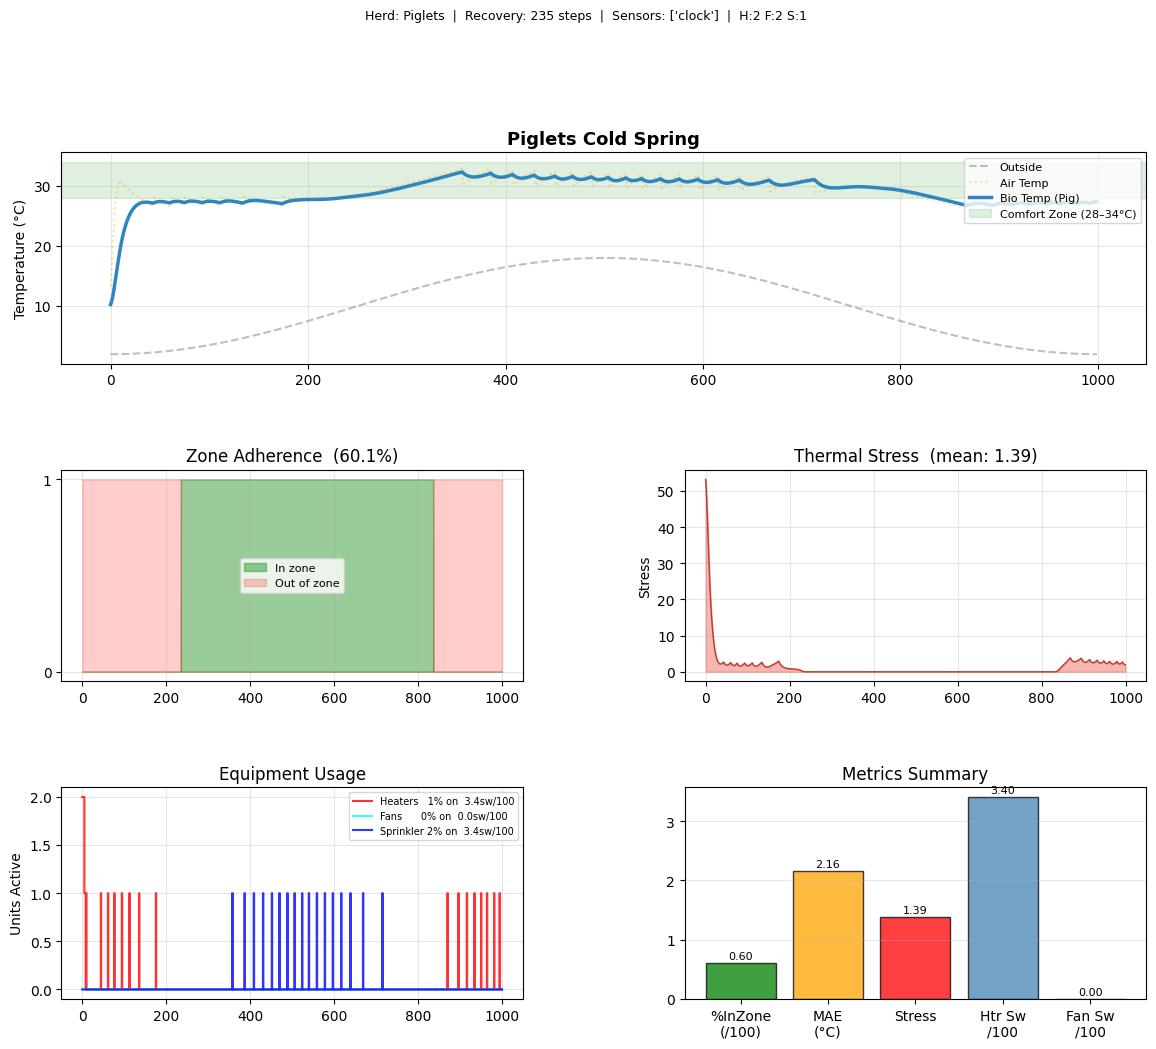

  Plot saved: eval_Piglets_Cold_Spring.png

  ──────────────────────────────────────────────────────
  Adults Brutal Summer
  ──────────────────────────────────────────────────────
  % in comfort zone       :   16.9%
  Mean abs error          :   3.88°C
  Mean thermal stress     :   1.22
  Recovery time           : 7 steps
  Heater   on: 51.0%   switch: 13.9/100 steps
  Fan      on: 43.9%   switch: 25.0/100 steps
  Sprinkler on:100.0%  switch:  0.0/100 steps


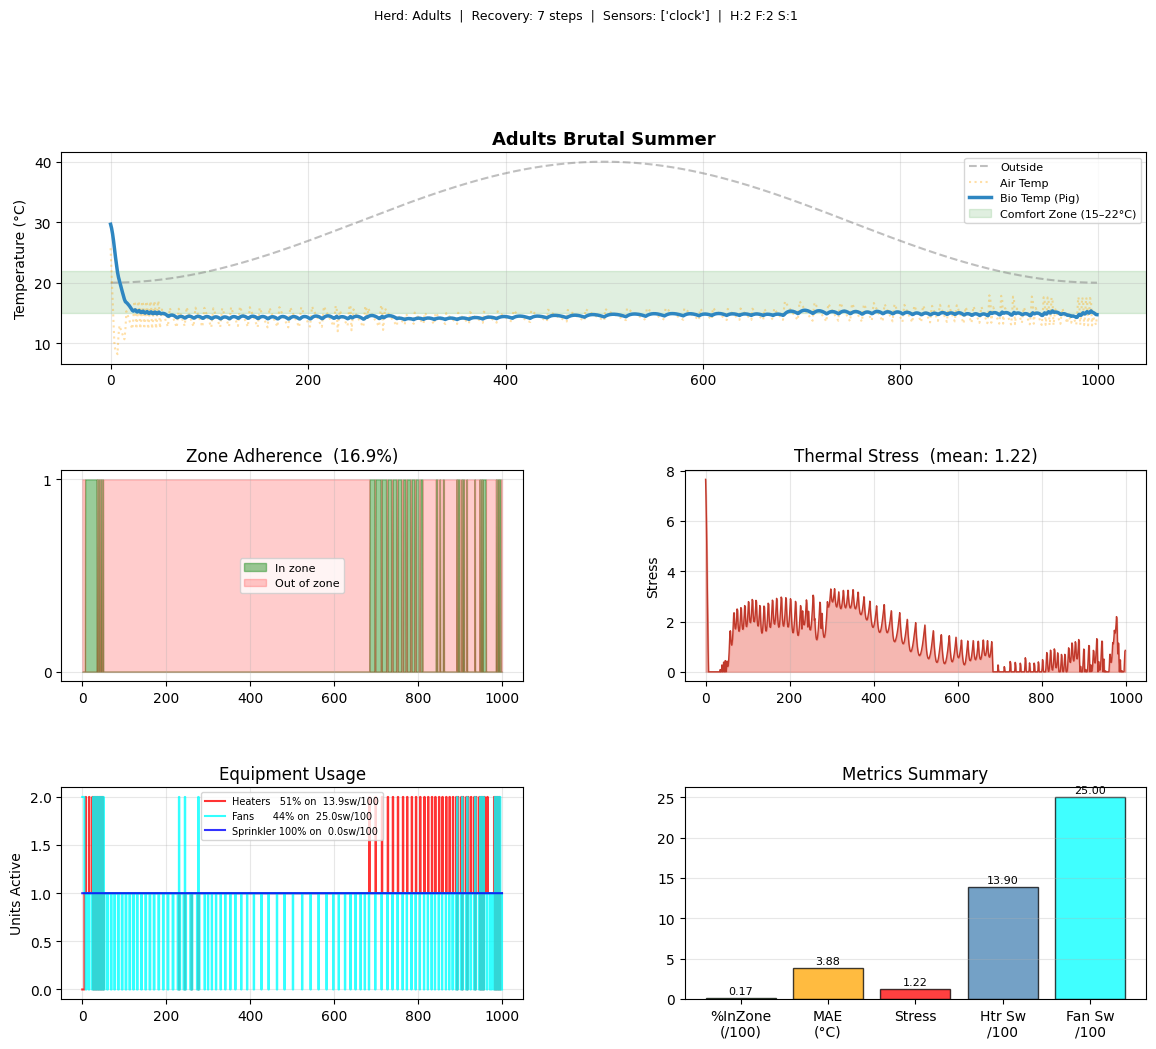

  Plot saved: eval_Adults_Brutal_Summer.png

  ──────────────────────────────────────────────────────
  Adults Sick Event
  ──────────────────────────────────────────────────────
  % in comfort zone       :   33.1%
  Mean abs error          :   3.72°C
  Mean thermal stress     :   0.91
  Recovery time           : started in zone
  Heater   on: 52.9%   switch: 15.1/100 steps
  Fan      on: 40.2%   switch: 31.6/100 steps
  Sprinkler on:100.0%  switch:  0.0/100 steps


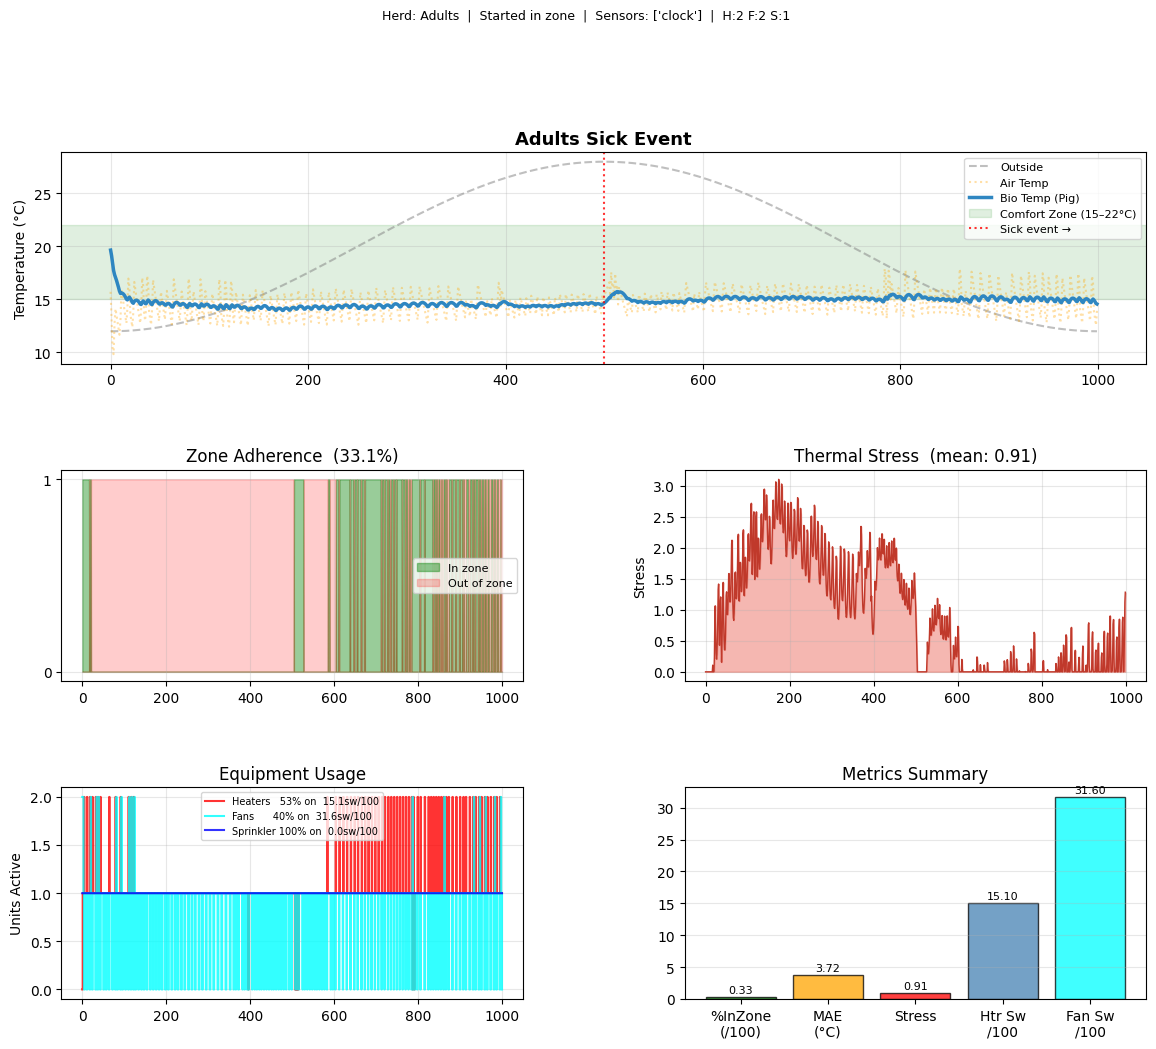

  Plot saved: eval_Adults_Sick_Event.png

  ──────────────────────────────────────────────────────
  Mixed Young Adults
  ──────────────────────────────────────────────────────
  % in comfort zone       :   25.7%
  Mean abs error          :   2.55°C
  Mean thermal stress     :   1.80
  Recovery time           : 3 steps
  Heater   on: 34.3%   switch: 95.5/100 steps
  Fan      on:  8.7%   switch: 33.8/100 steps
  Sprinkler on:100.0%  switch:  0.0/100 steps


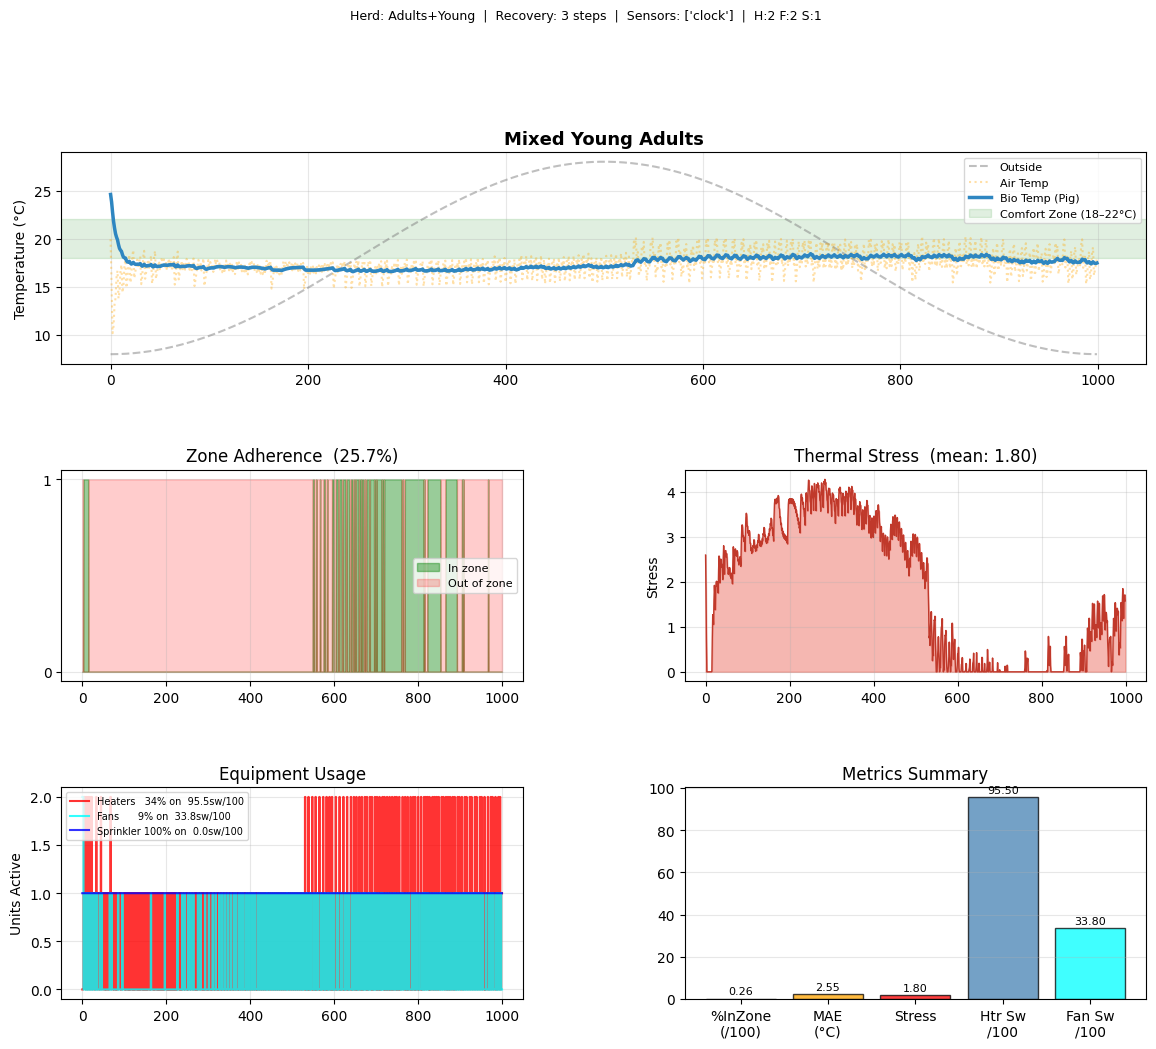

  Plot saved: eval_Mixed_Young_Adults.png

  ──────────────────────────────────────────────────────
  Adults Cold Recovery
  ──────────────────────────────────────────────────────
  % in comfort zone       :   49.5%
  Mean abs error          :   3.62°C
  Mean thermal stress     :   0.84
  Recovery time           : 384 steps
  Heater   on: 54.9%   switch: 31.1/100 steps
  Fan      on: 33.6%   switch: 35.9/100 steps
  Sprinkler on: 99.9%  switch:  0.1/100 steps


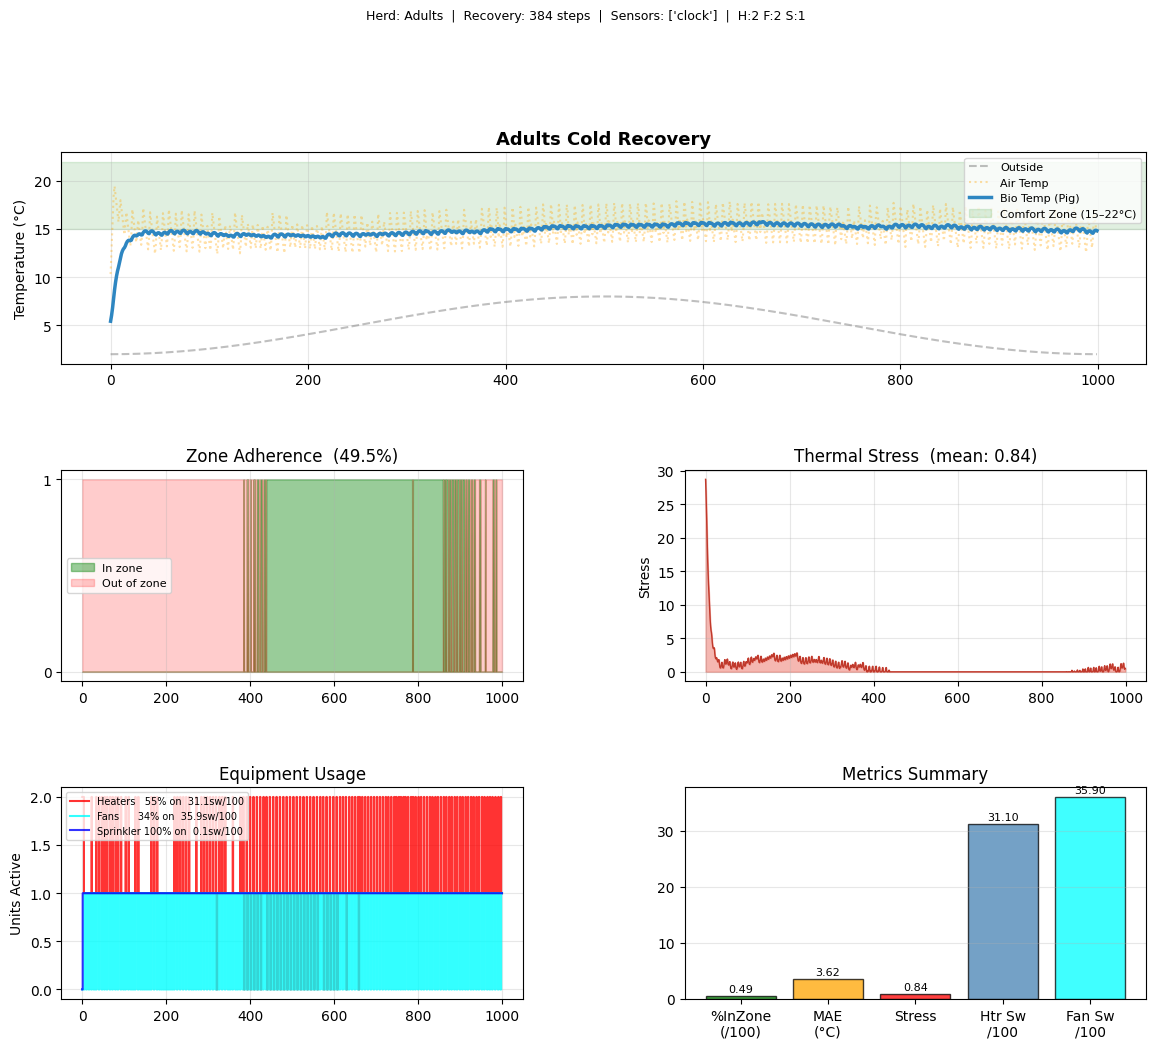

  Plot saved: eval_Adults_Cold_Recovery.png

  ──────────────────────────────────────────────────────
  Piglets Sick Event
  ──────────────────────────────────────────────────────
  % in comfort zone       :   76.1%
  Mean abs error          :   1.51°C
  Mean thermal stress     :   0.51
  Recovery time           : 165 steps
  Heater   on:  0.3%   switch:  1.1/100 steps
  Fan      on:  0.0%   switch:  0.0/100 steps
  Sprinkler on:  4.3%  switch:  8.6/100 steps


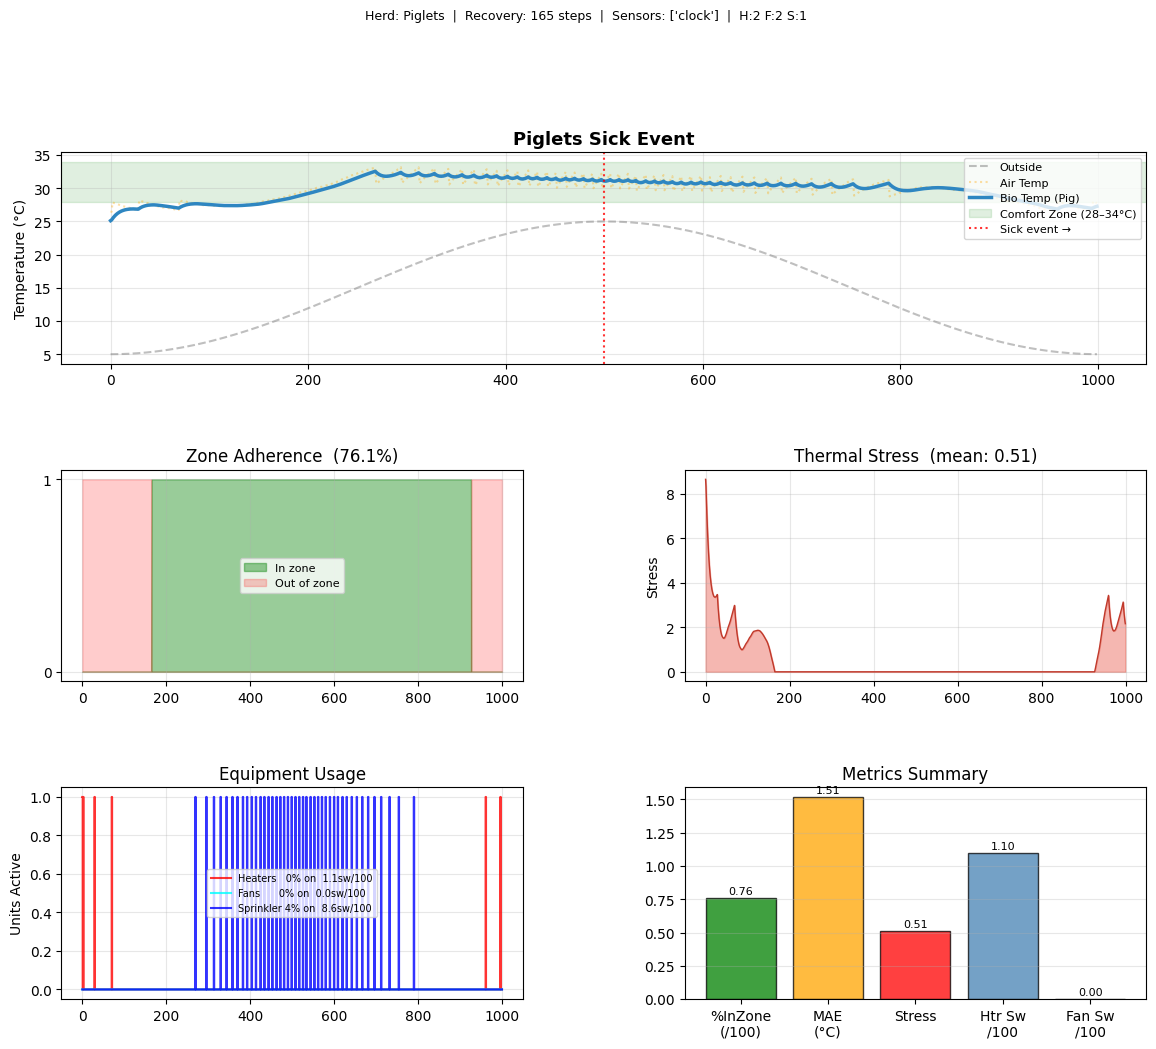

  Plot saved: eval_Piglets_Sick_Event.png

  ──────────────────────────────────────────────────────
  Young Mild Day
  ──────────────────────────────────────────────────────
  % in comfort zone       :   41.8%
  Mean abs error          :   4.30°C
  Mean thermal stress     :   1.59
  Recovery time           : started in zone
  Heater   on: 41.6%   switch:118.6/100 steps
  Fan      on:  0.1%   switch:  0.1/100 steps
  Sprinkler on:100.0%  switch:  0.0/100 steps


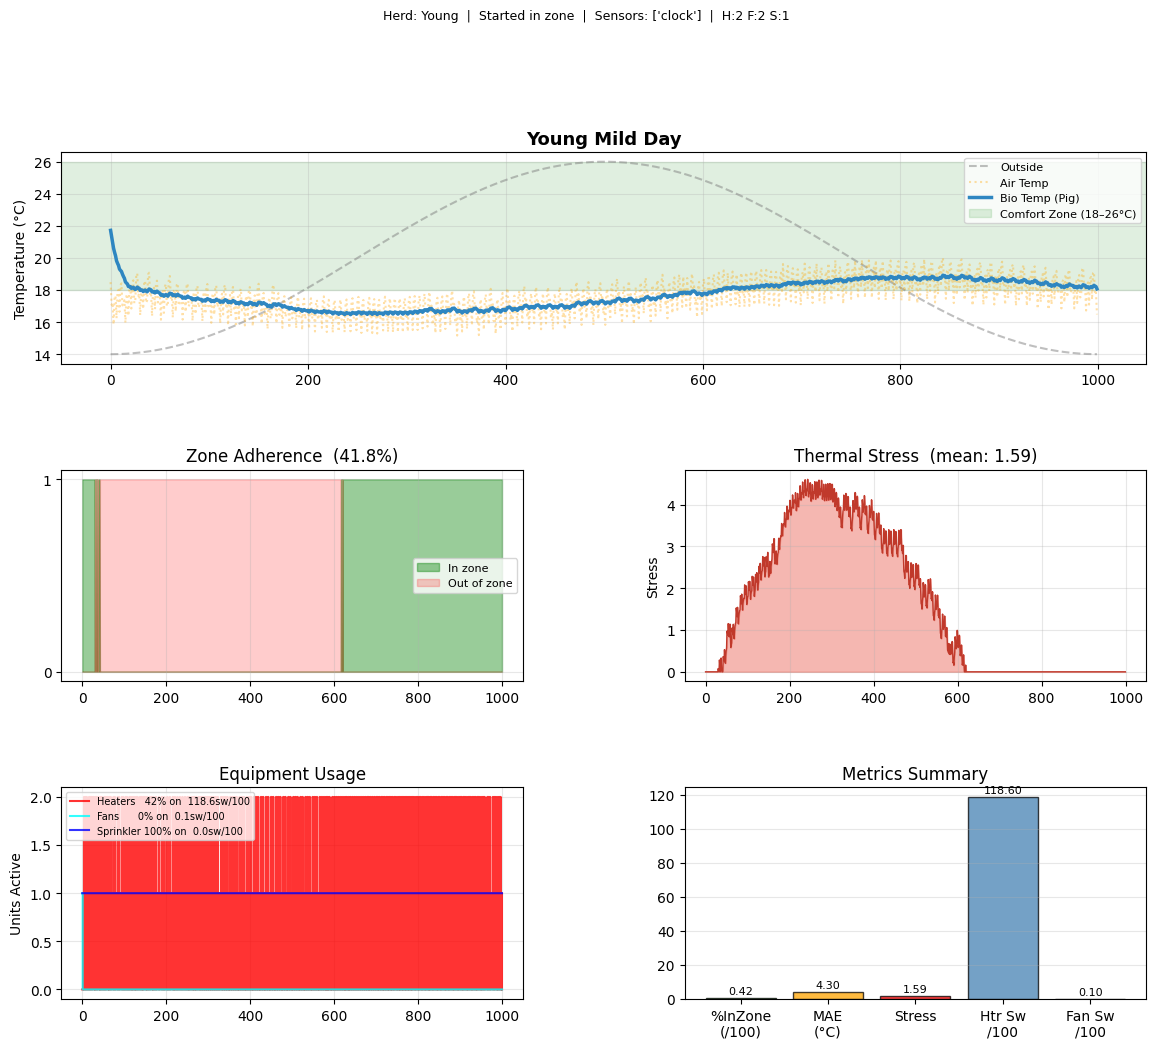

  Plot saved: eval_Young_Mild_Day.png

  ──────────────────────────────────────────────────────
  Diverse Herd
  ──────────────────────────────────────────────────────
  % in comfort zone       :    0.0%
  Mean abs error          :   4.52°C
  Mean thermal stress     :  22.57
  Recovery time           : started in zone
  Heater   on: 36.6%   switch:109.6/100 steps
  Fan      on:  0.0%   switch:  0.0/100 steps
  Sprinkler on:100.0%  switch:  0.0/100 steps


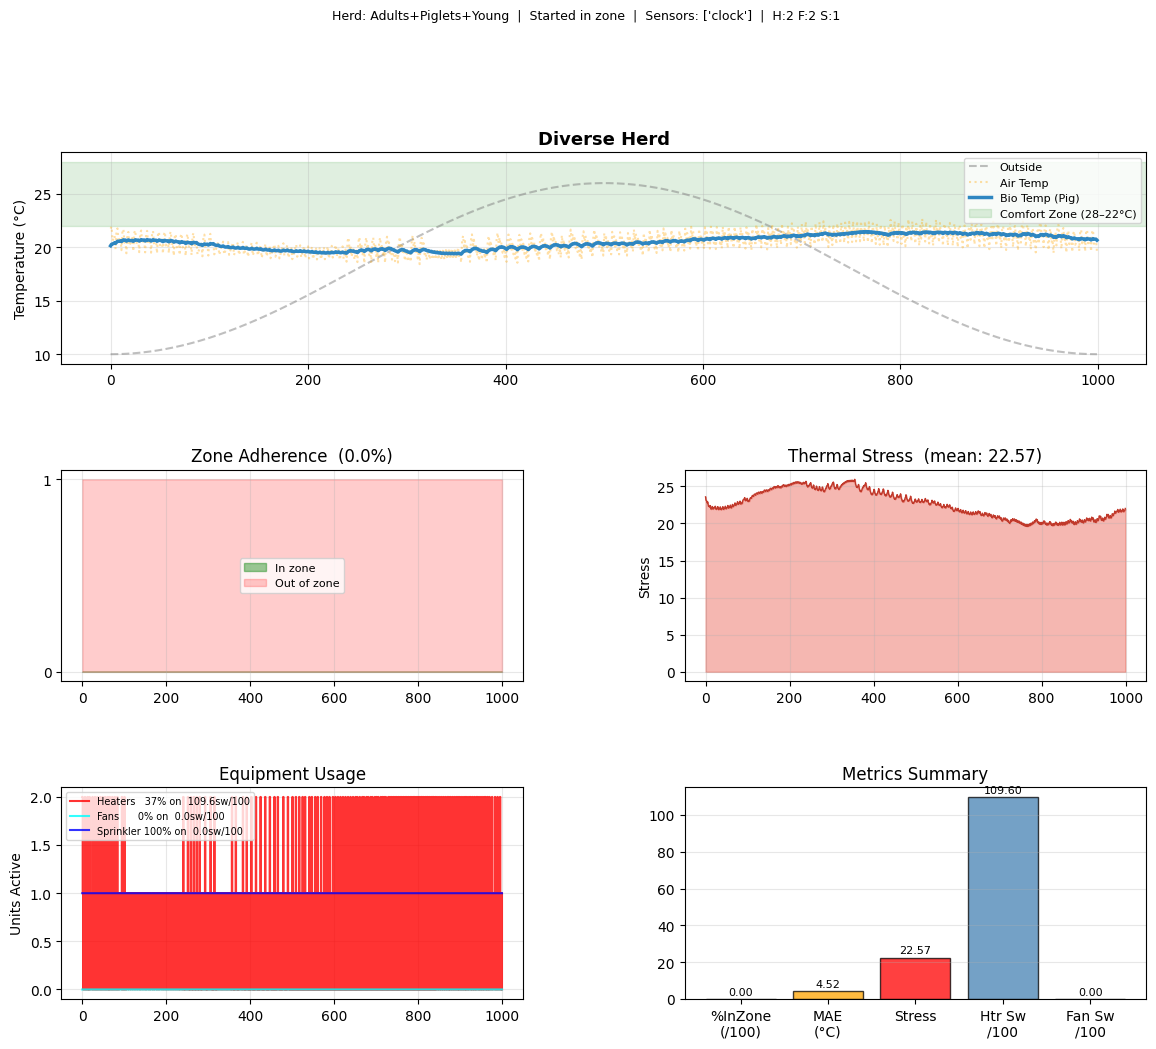

  Plot saved: eval_Diverse_Herd.png

  Cross-Scenario Comparison


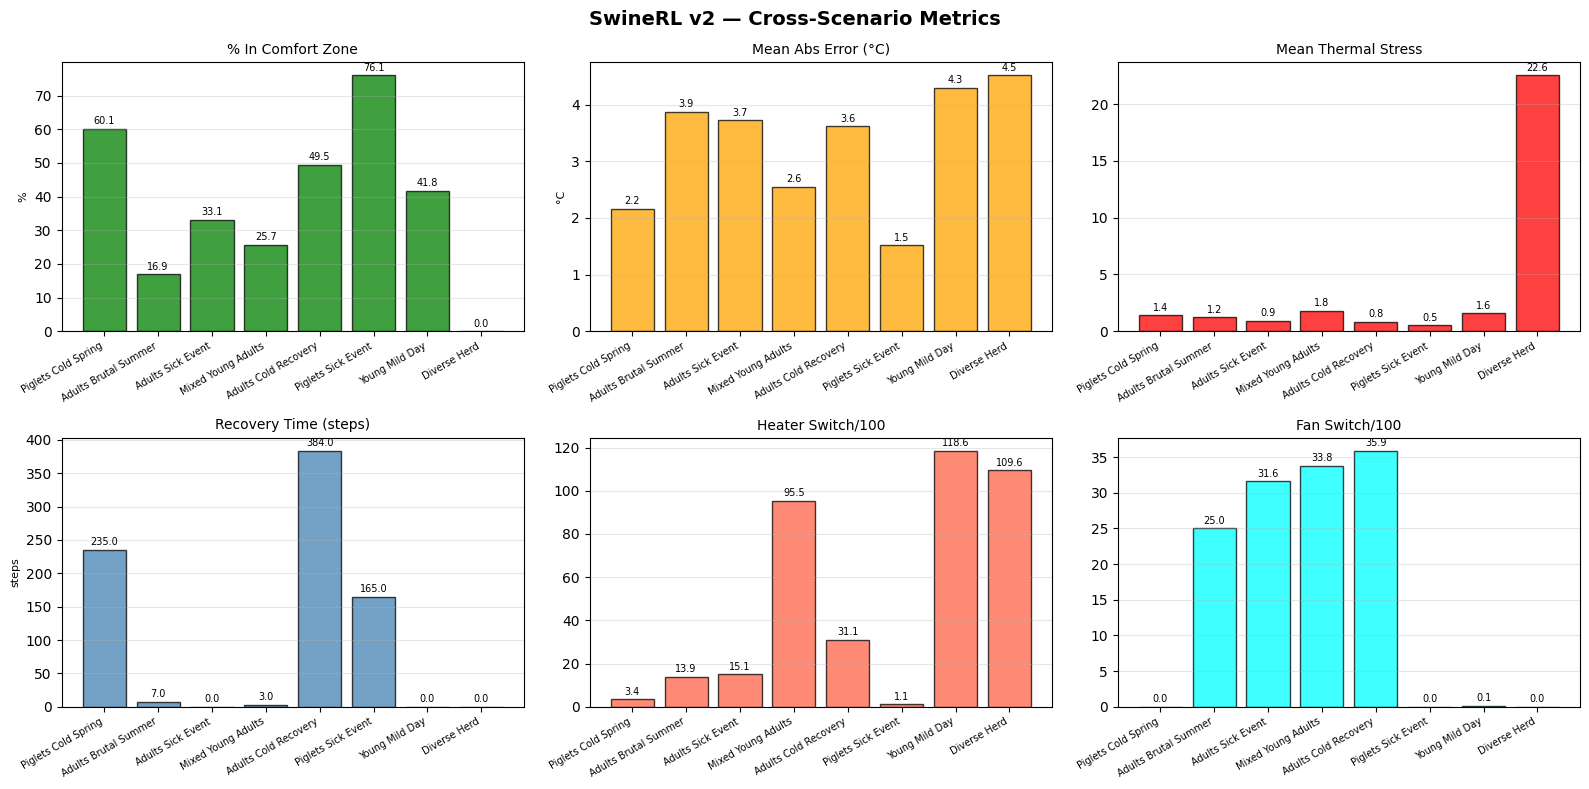

  Comparison saved: eval_comparison.png
  Done.


In [4]:
"""
SwineRL v2 — Evaluation Script
================================
Loads the single trained model and runs it against any sensor/equipment
config specified in config.json ["eval"] section.

Missing sensors → value zeroed + availability flag = 0.0
Missing equipment → action masked to 0 before env receives it

Metrics per scenario:
  - % timesteps inside comfort zone
  - Mean absolute error from zone centre
  - Mean thermal stress
  - Equipment on-rate (heaters, fans, sprinkler)
  - Equipment switching rate (toggles/100 steps) — hardware wear indicator
  - Recovery time from out-of-zone start
  - Cross-scenario comparison plot
"""

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

# ─────────────────────────────────────────────
# 1. LOAD CONFIG
# ─────────────────────────────────────────────
# CONFIG_PATH = "/kaggle/input/datasets/jheelgala/config/config.json"
# with open(CONFIG_PATH, "r") as f:
#     CFG = json.load(f)

HERD_CFG    = CFG["herd"]
EVAL_CFG    = CFG["eval"]
PHYSICS_CFG = CFG["physics"]
TRAIN_CFG   = CFG["training"]

COMFORT = {
    0: HERD_CFG["comfort_zones"]["piglets"],
    1: HERD_CFG["comfort_zones"]["young"],
    2: HERD_CFG["comfort_zones"]["adults"],
}

CFG["eval"]["equipment"]["sprinklers"] = 1

OBS_DIM     = 18
ACTION_NVEC = [2, 2, 2, 2, 2]

print("=" * 60)
print("  SwineRL v2 — Evaluation")
print("=" * 60)
print(f"\n  Eval sensors    : {EVAL_CFG['sensors']}")
print(f"  Eval equipment  : {EVAL_CFG['equipment']}")
print(f"  (Model trained with ALL sensors + equipment on)")


# ─────────────────────────────────────────────
# 2. STUB ENV FOR VECNORMALIZE
# ─────────────────────────────────────────────
class SwineEnvStub(gym.Env):
    """Minimal env — only needed to load VecNormalize stats."""
    def __init__(self):
        super().__init__()
        self.observation_space = spaces.Box(
            low  = np.full(OBS_DIM, -200, dtype=np.float32),
            high = np.full(OBS_DIM,  200, dtype=np.float32),
            dtype=np.float32
        )
        self.action_space = spaces.MultiDiscrete(ACTION_NVEC)
        self.comfort      = COMFORT
        # State variables
        self.air_temp = self.perceived_temp = 25.0
        self.humidity = 55.0
        self.co2      = 800.0
        self.clock_hour = 0.0
        self.heaters  = np.zeros(2, dtype=np.float32)
        self.fans     = np.zeros(2, dtype=np.float32)
        self.sprinkler = 0.0
        self.counts   = [0, 0, 8]
        self.current_herd = [2] * 8
        self.sick_event_active = False

    def reset(self, seed=None, options=None):
        self.air_temp = self.perceived_temp = 25.0
        return self._get_obs(), {}

    def _get_obs(self):
        return np.array([
            self.air_temp, self.perceived_temp,
            self.air_temp - self.perceived_temp,
            self.heaters[0], self.heaters[1],
            self.fans[0],    self.fans[1],
            self.sprinkler,
            float(self.counts[0]), float(self.counts[1]), float(self.counts[2]),
            self.humidity / 100.0,  1.0,
            self.co2 / 5000.0,      1.0,
            np.sin(2 * np.pi * self.clock_hour / 24),
            np.cos(2 * np.pi * self.clock_hour / 24), 1.0,
        ], dtype=np.float32)

    def step(self, action):
        return self._get_obs(), 0.0, False, False, {}


# ─────────────────────────────────────────────
# 3. LOAD MODEL + STATS
# ─────────────────────────────────────────────
eval_env = DummyVecEnv([lambda: SwineEnvStub()])
eval_env = VecNormalize.load("/kaggle/working/swine_vec_normalize_v2.pkl", eval_env)
eval_env.training    = False
eval_env.norm_reward = False
model = PPO.load("/kaggle/working/ppo_swine_v2.zip", device="cpu")


# ─────────────────────────────────────────────
# 4. OBS BUILDER WITH SENSOR MASKING
# ─────────────────────────────────────────────
def build_masked_obs(raw, eval_sensors):
    """
    Builds full 18-dim obs. Unavailable sensors → value=0, flag=0.
    Model learned to ignore flag=0 dimensions during training.
    """
    humidity_val  = raw.humidity / 100.0 if eval_sensors["humidity"] else 0.0
    humidity_flag = 1.0                  if eval_sensors["humidity"] else 0.0
    co2_val       = raw.co2 / 5000.0    if eval_sensors["co2"]      else 0.0
    co2_flag      = 1.0                  if eval_sensors["co2"]      else 0.0

    if eval_sensors["clock"]:
        cs, cc, cf = (np.sin(2*np.pi*raw.clock_hour/24),
                      np.cos(2*np.pi*raw.clock_hour/24), 1.0)
    else:
        cs = cc = cf = 0.0

    return np.array([
        raw.air_temp, raw.perceived_temp,
        raw.air_temp - raw.perceived_temp,
        raw.heaters[0], raw.heaters[1],
        raw.fans[0],    raw.fans[1],
        raw.sprinkler,
        float(raw.counts[0]), float(raw.counts[1]), float(raw.counts[2]),
        humidity_val, humidity_flag,
        co2_val,      co2_flag,
        cs, cc, cf,
    ], dtype=np.float32)


# ─────────────────────────────────────────────
# 5. ACTION MASKER
# ─────────────────────────────────────────────
def mask_action(action, eval_equipment):
    """Forces actions to 0 for equipment not present in eval config."""
    a = action.copy()
    n_heaters    = eval_equipment["heaters"]
    n_fans       = eval_equipment["fans"]
    n_sprinklers = eval_equipment["sprinklers"]
    if n_heaters    < 2: a[0, 1] = 0
    if n_heaters    < 1: a[0, 0] = 0
    if n_fans       < 2: a[0, 3] = 0
    if n_fans       < 1: a[0, 2] = 0
    if n_sprinklers < 1: a[0, 4] = 0
    return a


# ─────────────────────────────────────────────
# 6. METRICS
# ─────────────────────────────────────────────
def compute_metrics(bios, heater_hist, fan_hist, spr_hist, low_zone, high_zone):
    zone_centre = (low_zone + high_zone) / 2.0
    in_zone     = [1 if low_zone <= b <= high_zone else 0 for b in bios]
    pct_in_zone = 100.0 * np.mean(in_zone)
    mae         = np.mean([abs(b - zone_centre) for b in bios])
    stress_hist = [
        (low_zone - b)*3.0 if b < low_zone
        else (b - high_zone) if b > high_zone
        else 0.0
        for b in bios
    ]

    def on_rate(h, max_val=2): return (np.mean(h) / max_val) * 100
    def sw_rate(h):              return 100.0 * np.sum(np.abs(np.diff(h))) / max(len(h),1)

    recovery = next(
        (i for i, b in enumerate(bios) if low_zone <= b <= high_zone),
        None
    ) if (bios[0] < low_zone or bios[0] > high_zone) else None

    return dict(
        pct_in_zone     = pct_in_zone,
        mae             = mae,
        mean_stress     = float(np.mean(stress_hist)),
        heater_on       = on_rate(heater_hist, max_val=2),
        fan_on          = on_rate(fan_hist, max_val=2),
        sprinkler_on    = on_rate(spr_hist, max_val=1),
        heater_switch   = sw_rate(heater_hist),
        fan_switch      = sw_rate(fan_hist),
        sprinkler_switch= sw_rate(spr_hist),
        recovery        = recovery,
        in_zone         = in_zone,
        stress_hist     = stress_hist,
    )


def print_metrics(name, m):
    rt = f"{m['recovery']} steps" if m["recovery"] is not None else "started in zone"
    print(f"\n  {'─'*54}")
    print(f"  {name}")
    print(f"  {'─'*54}")
    print(f"  % in comfort zone       : {m['pct_in_zone']:>6.1f}%")
    print(f"  Mean abs error          : {m['mae']:>6.2f}°C")
    print(f"  Mean thermal stress     : {m['mean_stress']:>6.2f}")
    print(f"  Recovery time           : {rt}")
    print(f"  Heater   on:{m['heater_on']:>5.1f}%   switch:{m['heater_switch']:>5.1f}/100 steps")
    print(f"  Fan      on:{m['fan_on']:>5.1f}%   switch:{m['fan_switch']:>5.1f}/100 steps")
    print(f"  Sprinkler on:{m['sprinkler_on']:>5.1f}%  switch:{m['sprinkler_switch']:>5.1f}/100 steps")


# ─────────────────────────────────────────────
# 7. SCENARIO RUNNER
# ─────────────────────────────────────────────
def run_scenario(name, herd, start_temp, avg_out, amp,
                 has_sick=False, steps=1000, plot=True):
    raw = eval_env.envs[0].unwrapped
    eval_env.reset()

    raw.air_temp        = float(start_temp)
    raw.perceived_temp  = float(start_temp)
    raw.current_herd    = herd
    raw.counts          = [herd.count(i) for i in range(3)]
    raw.clock_hour      = 0.0
    raw.humidity        = 55.0
    raw.co2             = 800.0
    raw.heaters         = np.zeros(2, dtype=np.float32)
    raw.fans            = np.zeros(2, dtype=np.float32)
    raw.sprinkler       = 0.0
    raw.sick_event_active = False

    low_zone  = max([COMFORT[a][0] for a in herd])
    high_zone = min([COMFORT[a][1] for a in herd])

    bios, airs, ambients            = [], [], []
    heater_hist, fan_hist, spr_hist = [], [], []
    sick_flags                      = []

    eval_sensors   = EVAL_CFG["sensors"]
    eval_equipment = EVAL_CFG["equipment"]

    for t in range(steps):
        ambient = avg_out + amp * np.sin(2 * np.pi * t / steps - np.pi / 2)
        raw.air_temp += (ambient - raw.air_temp) * PHYSICS_CFG["ambient_drift_rate"]

        if has_sick and t == steps // 2:
            raw.sick_event_active = True
        if raw.sick_event_active and np.random.rand() > 0.95:
            raw.sick_event_active = False

        raw.clock_hour = (raw.clock_hour + 24.0 / steps) % 24

        obs   = build_masked_obs(raw, eval_sensors)
        obs_n = eval_env.normalize_obs(obs.reshape(1, -1))
        action, _ = model.predict(obs_n, deterministic=True)
        action = mask_action(action, eval_equipment)

        raw.heaters[0] = float(action[0, 0])
        raw.heaters[1] = float(action[0, 1])
        raw.fans[0]    = float(action[0, 2])
        raw.fans[1]    = float(action[0, 3])
        raw.sprinkler  = float(action[0, 4])

        met = PHYSICS_CFG["metabolic_heat"]
        metabolic = (raw.counts[0]*met["piglets"] +
                     raw.counts[1]*met["young"]   +
                     raw.counts[2]*met["adults"])
        if raw.sick_event_active:
            metabolic *= PHYSICS_CFG["sick_metabolic_multiplier"]

        heat_gain = np.sum(raw.heaters) * PHYSICS_CFG["heater_rate"] + metabolic
        cooling   = (np.sum(raw.fans)   * PHYSICS_CFG["fan_rate"] +
                     raw.sprinkler      * PHYSICS_CFG["sprinkler_cooling"])
        raw.air_temp      += heat_gain - cooling + np.random.normal(0, 0.02)
        raw.air_temp       = np.clip(raw.air_temp, 0, 50)
        raw.perceived_temp += (raw.air_temp - raw.perceived_temp) * PHYSICS_CFG["bio_latency"]

        raw.humidity += raw.sprinkler*3.0 - np.sum(raw.fans)*0.5 + np.random.normal(0, 0.3)
        raw.humidity  = np.clip(raw.humidity, 20, 100)
        raw.co2      += len(herd)*2.0 - np.sum(raw.fans)*50.0 + np.random.normal(0, 10)
        raw.co2       = np.clip(raw.co2, 400, 5000)

        bios.append(raw.perceived_temp)
        airs.append(raw.air_temp)
        ambients.append(ambient)
        heater_hist.append(float(np.sum(raw.heaters)))
        fan_hist.append(float(np.sum(raw.fans)))
        spr_hist.append(float(raw.sprinkler))
        sick_flags.append(int(raw.sick_event_active))

    m = compute_metrics(bios, heater_hist, fan_hist, spr_hist, low_zone, high_zone)
    print_metrics(name, m)

    if plot:
        x   = list(range(steps))
        fig = plt.figure(figsize=(14, 11))
        gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.50, wspace=0.35)
        ax1 = fig.add_subplot(gs[0, :])
        ax2 = fig.add_subplot(gs[1, 0])
        ax3 = fig.add_subplot(gs[1, 1])
        ax4 = fig.add_subplot(gs[2, 0])
        ax5 = fig.add_subplot(gs[2, 1])

        ax1.plot(x, ambients, color='gray',    alpha=0.5, linestyle='--', label='Outside')
        ax1.plot(x, airs,     color='orange',  alpha=0.35,linestyle=':',  label='Air Temp')
        ax1.plot(x, bios,     color='#2E86C1', linewidth=2.5,             label='Bio Temp (Pig)')
        ax1.axhspan(low_zone, high_zone, color='green', alpha=0.12,
                    label=f'Comfort Zone ({low_zone}–{high_zone}°C)')
        if has_sick:
            ax1.axvline(steps//2, color='red', linestyle=':', alpha=0.8, label='Sick event →')
        ax1.set_title(name, fontsize=13, fontweight='bold')
        ax1.set_ylabel('Temperature (°C)')
        ax1.legend(loc='upper right', fontsize=8)
        ax1.grid(True, alpha=0.3)

        ax2.fill_between(x, m["in_zone"],           color='green', alpha=0.4, label='In zone')
        ax2.fill_between(x, [1-v for v in m["in_zone"]], color='red', alpha=0.2, label='Out of zone')
        ax2.set_title(f'Zone Adherence  ({m["pct_in_zone"]:.1f}%)')
        ax2.set_yticks([0, 1])
        ax2.legend(fontsize=8)
        ax2.grid(True, alpha=0.3)

        ax3.fill_between(x, m["stress_hist"], color='#E74C3C', alpha=0.4)
        ax3.plot(x, m["stress_hist"], color='#C0392B', linewidth=1)
        ax3.set_title(f'Thermal Stress  (mean: {m["mean_stress"]:.2f})')
        ax3.set_ylabel('Stress')
        ax3.grid(True, alpha=0.3)

        ax4.step(x, heater_hist, where='post', color='red',  alpha=0.8,
                 label=f'Heaters   {m["heater_on"]:.0f}% on  {m["heater_switch"]:.1f}sw/100')
        ax4.step(x, fan_hist,    where='post', color='cyan', alpha=0.8,
                 label=f'Fans      {m["fan_on"]:.0f}% on  {m["fan_switch"]:.1f}sw/100')
        ax4.step(x, spr_hist,    where='post', color='blue', alpha=0.8,
                 label=f'Sprinkler {m["sprinkler_on"]:.0f}% on  {m["sprinkler_switch"]:.1f}sw/100')
        ax4.set_title('Equipment Usage')
        ax4.set_ylabel('Units Active')
        ax4.legend(fontsize=7)
        ax4.grid(True, alpha=0.3)

        labels = ['%InZone\n(/100)', 'MAE\n(°C)', 'Stress', 'Htr Sw\n/100', 'Fan Sw\n/100']
        values = [m['pct_in_zone']/100, m['mae'], m['mean_stress'],
                  m['heater_switch'], m['fan_switch']]
        clrs   = ['green', 'orange', 'red', 'steelblue', 'cyan']
        bars   = ax5.bar(labels, values, color=clrs, alpha=0.75, edgecolor='black')
        for bar, v in zip(bars, values):
            ax5.text(bar.get_x()+bar.get_width()/2,
                     bar.get_height()+max(values)*0.01,
                     f'{v:.2f}', ha='center', va='bottom', fontsize=8)
        ax5.set_title('Metrics Summary')
        ax5.grid(True, alpha=0.3, axis='y')

        age_names  = {0:"Piglets", 1:"Young", 2:"Adults"}
        herd_label = "+".join(sorted(set([age_names[a] for a in herd])))
        rt_str     = f"Recovery: {m['recovery']} steps" if m['recovery'] else "Started in zone"
        active_s   = [k for k,v in eval_sensors.items() if v]
        plt.suptitle(
            f'Herd: {herd_label}  |  {rt_str}  |  '
            f'Sensors: {active_s if active_s else "temp only"}  |  '
            f'H:{eval_equipment["heaters"]} F:{eval_equipment["fans"]} S:{eval_equipment["sprinklers"]}',
            fontsize=9, y=1.01
        )
        fname = f"eval_{name.replace(' ','_')}.png"
        plt.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"  Plot saved: {fname}")

    return m


# ─────────────────────────────────────────────
# 8. RUN SCENARIOS
# ─────────────────────────────────────────────
if __name__ == "__main__":
    all_results = {}

    scenarios = [
        dict(name="Piglets Cold Spring",  herd=[0]*8,             start_temp=10, avg_out=10, amp=8,  has_sick=False),
        dict(name="Adults Brutal Summer", herd=[2]*8,             start_temp=30, avg_out=30, amp=10, has_sick=False),
        dict(name="Adults Sick Event",    herd=[2]*8,             start_temp=20, avg_out=20, amp=8,  has_sick=True),
        dict(name="Mixed Young Adults",   herd=[1,1,1,1,2,2,2,2], start_temp=25, avg_out=18, amp=10, has_sick=False),
        dict(name="Adults Cold Recovery", herd=[2]*8,             start_temp=5,  avg_out=5,  amp=3,  has_sick=False),
        dict(name="Piglets Sick Event",   herd=[0]*8,             start_temp=25, avg_out=15, amp=10, has_sick=True),
        dict(name="Young Mild Day",       herd=[1]*8,             start_temp=22, avg_out=20, amp=6,  has_sick=False),
        dict(name="Diverse Herd",         herd=[0,0,1,1,1,2,2,2], start_temp=20, avg_out=18, amp=8,  has_sick=False),
        
    ]

    for sc in scenarios:
        all_results[sc["name"]] = run_scenario(**sc)

    # ── Cross-scenario comparison ─────────────────────────────────────────
    print("\n" + "="*60)
    print("  Cross-Scenario Comparison")
    print("="*60)

    names    = list(all_results.keys())
    metrics  = {
        "% In Comfort Zone":     ([all_results[n]["pct_in_zone"]       for n in names], "green",     "%"),
        "Mean Abs Error (°C)":   ([all_results[n]["mae"]               for n in names], "orange",    "°C"),
        "Mean Thermal Stress":   ([all_results[n]["mean_stress"]       for n in names], "red",       ""),
        "Recovery Time (steps)": ([all_results[n]["recovery"] or 0     for n in names], "steelblue", "steps"),
        "Heater Switch/100":     ([all_results[n]["heater_switch"]     for n in names], "tomato",    ""),
        "Fan Switch/100":        ([all_results[n]["fan_switch"]        for n in names], "cyan",      ""),
    }

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    fig.suptitle("SwineRL v2 — Cross-Scenario Metrics", fontsize=14, fontweight='bold')

    for ax, (title, (vals, color, unit)) in zip(axes.flat, metrics.items()):
        bars = ax.bar(range(len(names)), vals, color=color, alpha=0.75, edgecolor='black')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+max(vals+[0.001])*0.01,
                    f'{v:.1f}', ha='center', va='bottom', fontsize=7)
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels(names, rotation=30, ha='right', fontsize=7)
        ax.set_title(title, fontsize=10)
        ax.set_ylabel(unit, fontsize=8)
        ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig("eval_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("  Comparison saved: eval_comparison.png")
    print("  Done.")


### 6) Finetune the Policy
This cell continues training from the saved checkpoint with stricter control penalties and updated hyperparameters to reduce undesirable actuator behavior.

In [6]:
"""
SwineRL v2 — Finetuning Script
================================
Loads the saved model + VecNormalize stats and continues training
with sharpened penalties to fix:
  - Sprinkler stuck at 100% in hot scenarios
  - Heater chattering in mild scenarios

Changes vs original training:
  - Simultaneous heater+fan penalty: -2.0 → -4.0
  - New switching penalty: -1.0 per heater toggle, -0.5 per fan toggle
  - 1M additional steps (enough to sharpen without forgetting)
  - Entropy starts at 0.01 (low — policy already shaped, just refining)
"""

import json
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.callbacks import BaseCallback

# ─────────────────────────────────────────────
# CONFIG — inline to avoid file path issues
# ─────────────────────────────────────────────
import json
config_str = """
{
  "herd": {
    "counts": {"piglets": 0, "young": 0, "adults": 8},
    "comfort_zones": {
      "piglets": [28, 34],
      "young":   [18, 26],
      "adults":  [15, 22],
      "source":  "default"
    }
  },
  "training": {
    "sensors": {"humidity": true, "co2": true, "clock": true},
    "equipment": {"heaters": 2, "fans": 2, "sprinklers": 1},
    "total_timesteps": 1000000,
    "learning_rate": 0.0001,
    "n_steps": 4096,
    "batch_size": 128,
    "ent_coef": 0.01,
    "device": "cuda",
    "save_path": "/kaggle/working/ppo_swine_v2_ft",
    "stats_path": "/kaggle/working/swine_vec_normalize_v2_ft.pkl"
  },
  "physics": {
    "heater_rate": 1.5,
    "fan_rate": 2.0,
    "sprinkler_cooling": 2.5,
    "bio_latency": 0.08,
    "ambient_drift_rate": 0.02,
    "noise_std": 0.05,
    "metabolic_heat": {"piglets": 0.05, "young": 0.15, "adults": 0.30},
    "sick_metabolic_multiplier": 1.25,
    "sick_event_probability": 0.30
  },
  "environment": {"temp_min": 0, "temp_max": 50, "max_steps": 1000}
}
"""
CFG         = json.loads(config_str)
HERD_CFG    = CFG["herd"]
TRAIN_CFG   = CFG["training"]
PHYSICS_CFG = CFG["physics"]
ENV_CFG     = CFG["environment"]

COMFORT = {
    0: HERD_CFG["comfort_zones"]["piglets"],
    1: HERD_CFG["comfort_zones"]["young"],
    2: HERD_CFG["comfort_zones"]["adults"],
}

OBS_DIM     = 18
ACTION_NVEC = [2, 2, 2, 2, 2]
TOTAL_PIGS  = 8

step_counter = {"n": 0}

print(f"Comfort zones : {COMFORT}")
print(f"Finetuning for {TRAIN_CFG['total_timesteps']:,} steps")
print(f"Saving to     : {TRAIN_CFG['save_path']}")


# ─────────────────────────────────────────────
# ENVIRONMENT — identical to training except:
#   1. Simultaneous penalty raised to -4.0
#   2. Switching penalty added
# ─────────────────────────────────────────────
class SwineEnvV2FT(gym.Env):
    def __init__(self, step_counter=step_counter):
        super().__init__()
        self.step_counter = step_counter
        self.physics      = PHYSICS_CFG
        self.env_cfg      = ENV_CFG
        self.comfort      = COMFORT
        self.max_steps    = ENV_CFG["max_steps"]

        self.observation_space = spaces.Box(
            low  = np.full(OBS_DIM, -200, dtype=np.float32),
            high = np.full(OBS_DIM,  200, dtype=np.float32),
            dtype=np.float32
        )
        self.action_space = spaces.MultiDiscrete(ACTION_NVEC)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        steps = self.step_counter["n"]
        if steps < 300_000:
            self.current_herd = [2] * 8
        elif steps < 600_000:
            self.current_herd = np.random.choice([1, 2], size=8).tolist()
        else:
            self.current_herd = np.random.choice([0, 1, 2], size=8).tolist()

        self.counts = [self.current_herd.count(i) for i in range(3)]

        if np.random.rand() > 0.5:
            dominant = max([0, 1, 2], key=lambda a: self.current_herd.count(a))
            l, u = self.comfort[dominant]
            start = float(np.random.uniform(l - 3, u + 3))
        else:
            start = float(np.random.uniform(5, 45))

        self.air_temp       = np.clip(start, 0, 50)
        self.perceived_temp = self.air_temp
        self.humidity       = float(np.random.uniform(40, 70))
        self.co2            = float(np.random.uniform(400, 1500))
        self.clock_hour     = float(np.random.uniform(0, 24))

        self.heaters   = np.zeros(2, dtype=np.float32)
        self.fans      = np.zeros(2, dtype=np.float32)
        self.sprinkler = 0.0

        # Track previous equipment state for switching penalty
        self._prev_heaters = np.zeros(2, dtype=np.float32)
        self._prev_fans    = np.zeros(2, dtype=np.float32)

        self.current_step      = 0
        self.sick_event_active = np.random.rand() < self.physics["sick_event_probability"]
        return self._get_obs(), {}

    def _get_obs(self):
        return np.array([
            self.air_temp,
            self.perceived_temp,
            self.air_temp - self.perceived_temp,
            self.heaters[0], self.heaters[1],
            self.fans[0],    self.fans[1],
            self.sprinkler,
            float(self.counts[0]),
            float(self.counts[1]),
            float(self.counts[2]),
            self.humidity / 100.0, 1.0,
            self.co2 / 5000.0,     1.0,
            np.sin(2 * np.pi * self.clock_hour / 24),
            np.cos(2 * np.pi * self.clock_hour / 24),
            1.0,
        ], dtype=np.float32)

    def step(self, action):
        self.current_step += 1

        self.heaters[0] = float(action[0])
        self.heaters[1] = float(action[1])
        self.fans[0]    = float(action[2])
        self.fans[1]    = float(action[3])
        self.sprinkler  = float(action[4])

        met = self.physics["metabolic_heat"]
        metabolic = (
            self.counts[0] * met["piglets"] +
            self.counts[1] * met["young"]   +
            self.counts[2] * met["adults"]
        )
        if self.sick_event_active:
            metabolic *= self.physics["sick_metabolic_multiplier"]

        heat_gain = np.sum(self.heaters) * self.physics["heater_rate"] + metabolic
        cooling   = (
            np.sum(self.fans)  * self.physics["fan_rate"] +
            self.sprinkler     * self.physics["sprinkler_cooling"]
        )
        self.air_temp += heat_gain - cooling + np.random.normal(0, self.physics["noise_std"])
        self.air_temp  = np.clip(self.air_temp, self.env_cfg["temp_min"], self.env_cfg["temp_max"])
        self.perceived_temp += (self.air_temp - self.perceived_temp) * self.physics["bio_latency"]

        self.humidity += (
            self.sprinkler * 3.0
            - np.sum(self.fans) * 0.5
            + np.random.normal(0, 0.5)
        )
        self.humidity = np.clip(self.humidity, 20, 100)

        self.co2 += (
            TOTAL_PIGS * 2.0
            - np.sum(self.fans) * 50.0
            + np.random.normal(0, 10)
        )
        self.co2 = np.clip(self.co2, 400, 5000)

        self.clock_hour = (self.clock_hour + 24.0 / self.max_steps) % 24

        if self.sick_event_active:
            if np.random.rand() > 0.95:
                self.sick_event_active = False
        else:
            if np.random.rand() < 0.005:
                self.sick_event_active = True

        # Thermal stress reward
        thermal_stress = 0.0
        for age in self.current_herd:
            l, u = self.comfort[age]
            if self.perceived_temp < l:
                thermal_stress += (l - self.perceived_temp) * 3.0
            elif self.perceived_temp > u:
                thermal_stress += (self.perceived_temp - u)

        reward = -(thermal_stress / len(self.current_herd) * 4.0)
        if thermal_stress == 0:
            reward += 10.0

        # Simultaneous heater+fan penalty — raised from -2.0 to -4.0
        if np.sum(self.heaters) > 0 and np.sum(self.fans) > 0:
            reward -= 4.0

        # Sprinkler when humidity high
        if self.sprinkler > 0 and self.humidity > 75:
            reward -= 3.0

        # Switching penalty — discourages rapid toggling
        heater_change = np.sum(np.abs(self.heaters - self._prev_heaters))
        fan_change    = np.sum(np.abs(self.fans    - self._prev_fans))
        if heater_change > 0:
            reward -= 1.0 * heater_change
        if fan_change > 0:
            reward -= 0.5 * fan_change

        # Store for next step
        self._prev_heaters = self.heaters.copy()
        self._prev_fans    = self.fans.copy()

        done = self.current_step >= self.max_steps
        return self._get_obs(), float(reward), done, False, {}


# ─────────────────────────────────────────────
# CALLBACK
# ─────────────────────────────────────────────
class FinetuneLogger(BaseCallback):
    def __init__(self, log_interval=10000, total_timesteps=1_000_000):
        super().__init__(verbose=0)
        self.log_interval    = log_interval
        self.total_timesteps = total_timesteps
        self.episode_rewards = []
        self._ep_reward      = 0

    def _on_step(self):
        step_counter["n"] = self.num_timesteps

        # Entropy stays low and fixed during finetuning
        self._ep_reward += self.locals["rewards"][0]
        if self.locals["dones"][0]:
            self.episode_rewards.append(self._ep_reward)
            self._ep_reward = 0

        if self.num_timesteps % self.log_interval == 0 and self.episode_rewards:
            recent = self.episode_rewards[-20:]
            print(
                f"  [{self.num_timesteps:>7} steps] "
                f"mean: {np.mean(recent):>8.1f}  "
                f"min: {np.min(recent):>8.1f}  "
                f"max: {np.max(recent):>8.1f}  "
                f"| eps: {len(self.episode_rewards)}"
            )
        return True


# ─────────────────────────────────────────────
# FINETUNE
# ─────────────────────────────────────────────
if __name__ == "__main__":
    print("\n" + "=" * 60)
    print("  SwineRL v2 — Finetuning")
    print("=" * 60)

    N_ENVS = 8

    def make_env():
        return Monitor(SwineEnvV2FT(step_counter))

    # Load existing stats and continue updating them
    venv = DummyVecEnv([make_env] * N_ENVS)
    venv = VecNormalize.load(
        "/kaggle/working/swine_vec_normalize_v2.pkl", venv
    )
    venv.training    = True   # keep updating normalisation stats
    venv.norm_reward = False

    # Load existing weights into new env
    model = PPO.load(
        "/kaggle/working/ppo_swine_v2.zip",
        env    = venv,
        device = "cuda",
        # Override hyperparams for finetuning
        learning_rate = TRAIN_CFG["learning_rate"],  # 1e-4 — lower than training
        ent_coef      = TRAIN_CFG["ent_coef"],        # 0.01 — low, policy already shaped
    )

    print(f"\n  Loaded model  : /kaggle/working/ppo_swine_v2.zip")
    print(f"  Loaded stats  : /kaggle/working/swine_vec_normalize_v2.pkl")
    print(f"  Finetune steps: {TRAIN_CFG['total_timesteps']:,}")
    print(f"  Learning rate : {TRAIN_CFG['learning_rate']}")
    print(f"  Ent coef      : {TRAIN_CFG['ent_coef']}  (fixed, no decay)")
    print(f"  New penalties : simultaneous=-4.0, switch_htr=-1.0, switch_fan=-0.5")
    print(f"\n  Log (every 10k steps):")
    print("  " + "-" * 58)

    model.learn(
        total_timesteps = TRAIN_CFG["total_timesteps"],
        callback        = FinetuneLogger(
            log_interval    = 10000,
            total_timesteps = TRAIN_CFG["total_timesteps"],
        ),
        reset_num_timesteps = False   # continue step count from where training left off
    )

    model.save(TRAIN_CFG["save_path"])
    venv.save(TRAIN_CFG["stats_path"])

    print("  " + "-" * 58)
    print(f"\n  Done.")
    print(f"  Model → {TRAIN_CFG['save_path']}.zip")
    print(f"  Stats → {TRAIN_CFG['stats_path']}")

Comfort zones : {0: [28, 34], 1: [18, 26], 2: [15, 22]}
Finetuning for 1,000,000 steps
Saving to     : /kaggle/working/ppo_swine_v2_ft

  SwineRL v2 — Finetuning

  Loaded model  : /kaggle/working/ppo_swine_v2.zip
  Loaded stats  : /kaggle/working/swine_vec_normalize_v2.pkl
  Finetune steps: 1,000,000
  Learning rate : 0.0001
  Ent coef      : 0.01  (fixed, no decay)
  New penalties : simultaneous=-4.0, switch_htr=-1.0, switch_fan=-0.5

  Log (every 10k steps):
  ----------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


  [2040000 steps] mean:   3057.9  min:   3057.9  max:   3057.9  | eps: 1
  [2050000 steps] mean:  -5661.0  min: -14380.0  max:   3057.9  | eps: 2
  [2060000 steps] mean:  -8704.8  min: -14792.4  max:   3057.9  | eps: 3
  [2070000 steps] mean: -10431.0  min: -15609.7  max:   3057.9  | eps: 4
  [2080000 steps] mean: -10812.7  min: -15609.7  max:   3057.9  | eps: 6
  [2090000 steps] mean: -10691.8  min: -15609.7  max:   3057.9  | eps: 7
  [2100000 steps] mean: -11266.6  min: -15609.7  max:   3057.9  | eps: 8
  [2110000 steps] mean: -11487.8  min: -15609.7  max:   3057.9  | eps: 9
  [2120000 steps] mean: -11781.7  min: -15609.7  max:   3057.9  | eps: 11
  [2130000 steps] mean: -12057.8  min: -15609.7  max:   3057.9  | eps: 12
  [2140000 steps] mean: -12139.0  min: -15609.7  max:   3057.9  | eps: 13
  [2150000 steps] mean: -12253.9  min: -15609.7  max:   3057.9  | eps: 14
  [2160000 steps] mean: -12198.6  min: -15609.7  max:   3057.9  | eps: 16
  [2170000 steps] mean: -11916.4  min: -15609.

### 7) Evaluate the Finetuned Model
This final evaluation cell assesses performance after finetuning using the same metrics/plots, so you can compare behavior against the earlier baseline run.

  SwineRL v2 — Evaluation

  Eval sensors    : {'humidity': False, 'co2': False, 'clock': True}
  Eval equipment  : {'heaters': 2, 'fans': 2, 'sprinklers': 1}
  (Model trained with ALL sensors + equipment on)

  ──────────────────────────────────────────────────────
  Piglets Cold Spring
  ──────────────────────────────────────────────────────
  % in comfort zone       :   80.8%
  Mean abs error          :   2.11°C
  Mean thermal stress     :   1.00
  Recovery time           : 31 steps
  Heater   on:  1.9%   switch:  3.4/100 steps
  Fan      on:  0.0%   switch:  0.0/100 steps
  Sprinkler on:  2.4%  switch:  4.8/100 steps


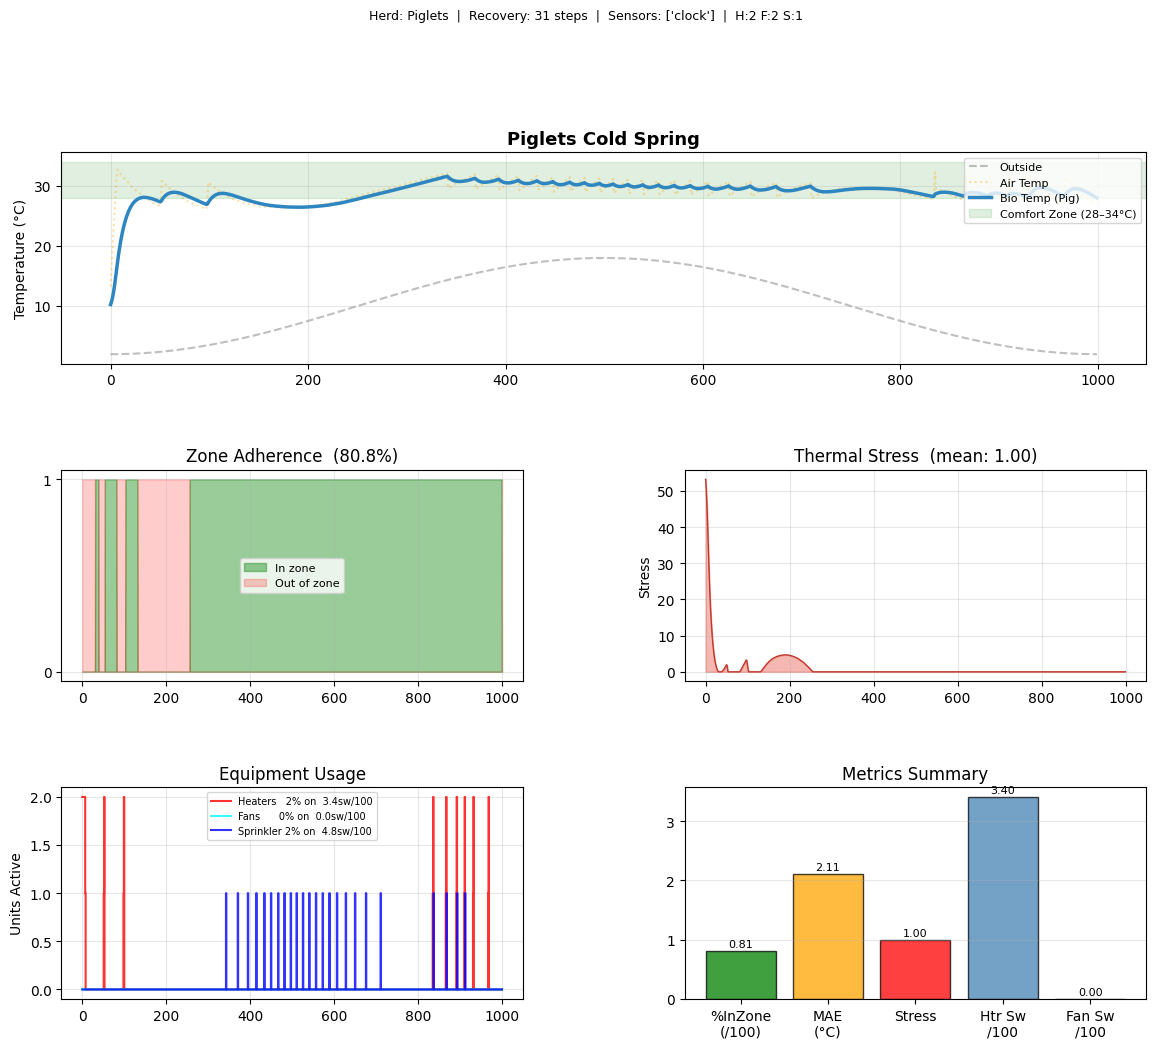

  Plot saved: eval_Piglets_Cold_Spring.png

  ──────────────────────────────────────────────────────
  Adults Brutal Summer
  ──────────────────────────────────────────────────────
  % in comfort zone       :   99.0%
  Mean abs error          :   1.50°C
  Mean thermal stress     :   0.04
  Recovery time           : 10 steps
  Heater   on: 99.8%   switch:  0.2/100 steps
  Fan      on: 79.1%   switch: 24.3/100 steps
  Sprinkler on:100.0%  switch:  0.0/100 steps


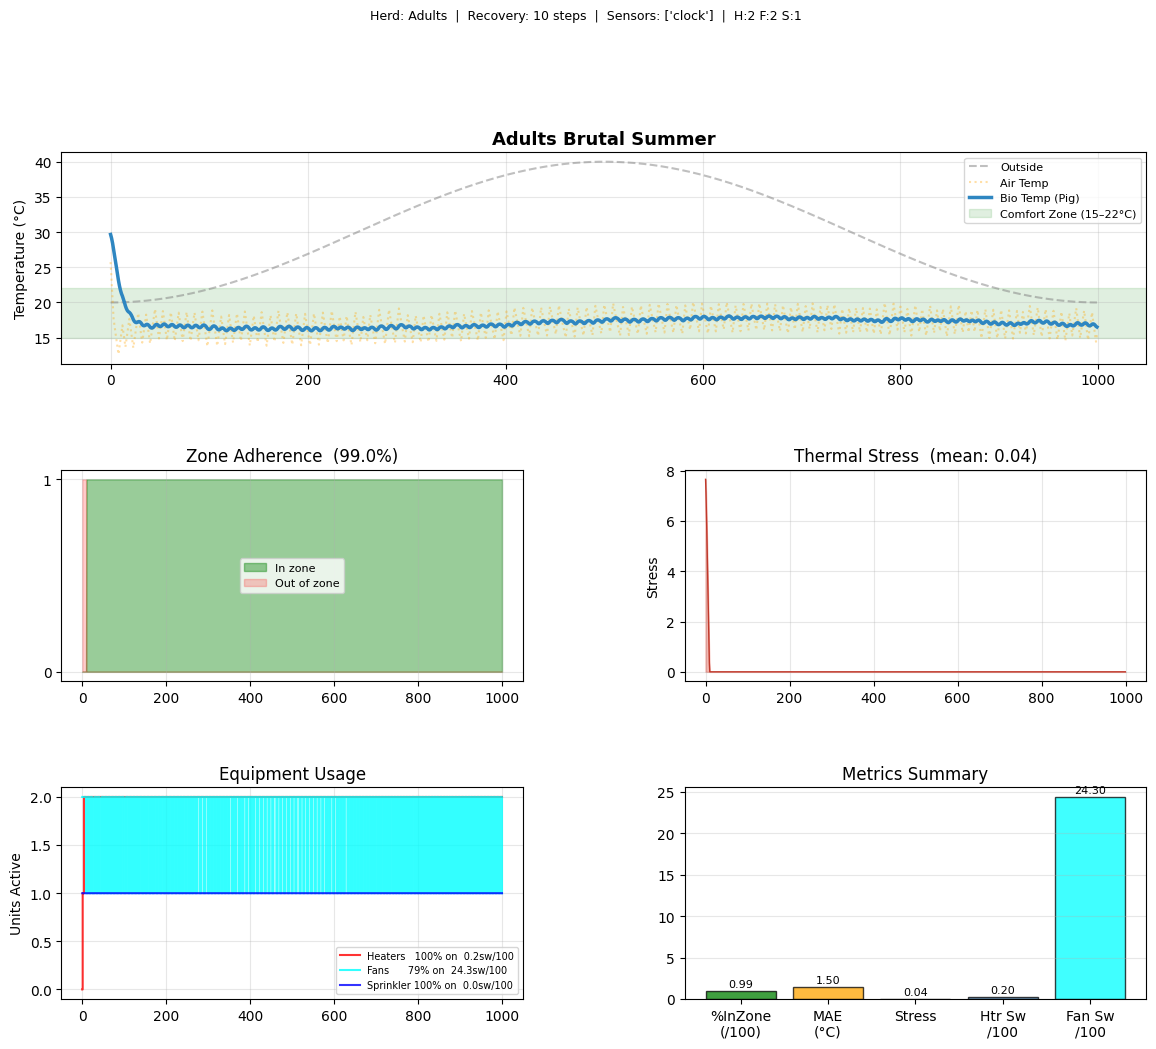

  Plot saved: eval_Adults_Brutal_Summer.png

  ──────────────────────────────────────────────────────
  Adults Sick Event
  ──────────────────────────────────────────────────────
  % in comfort zone       :  100.0%
  Mean abs error          :   1.37°C
  Mean thermal stress     :   0.00
  Recovery time           : started in zone
  Heater   on:100.0%   switch:  0.0/100 steps
  Fan      on: 74.5%   switch: 25.0/100 steps
  Sprinkler on:100.0%  switch:  0.0/100 steps


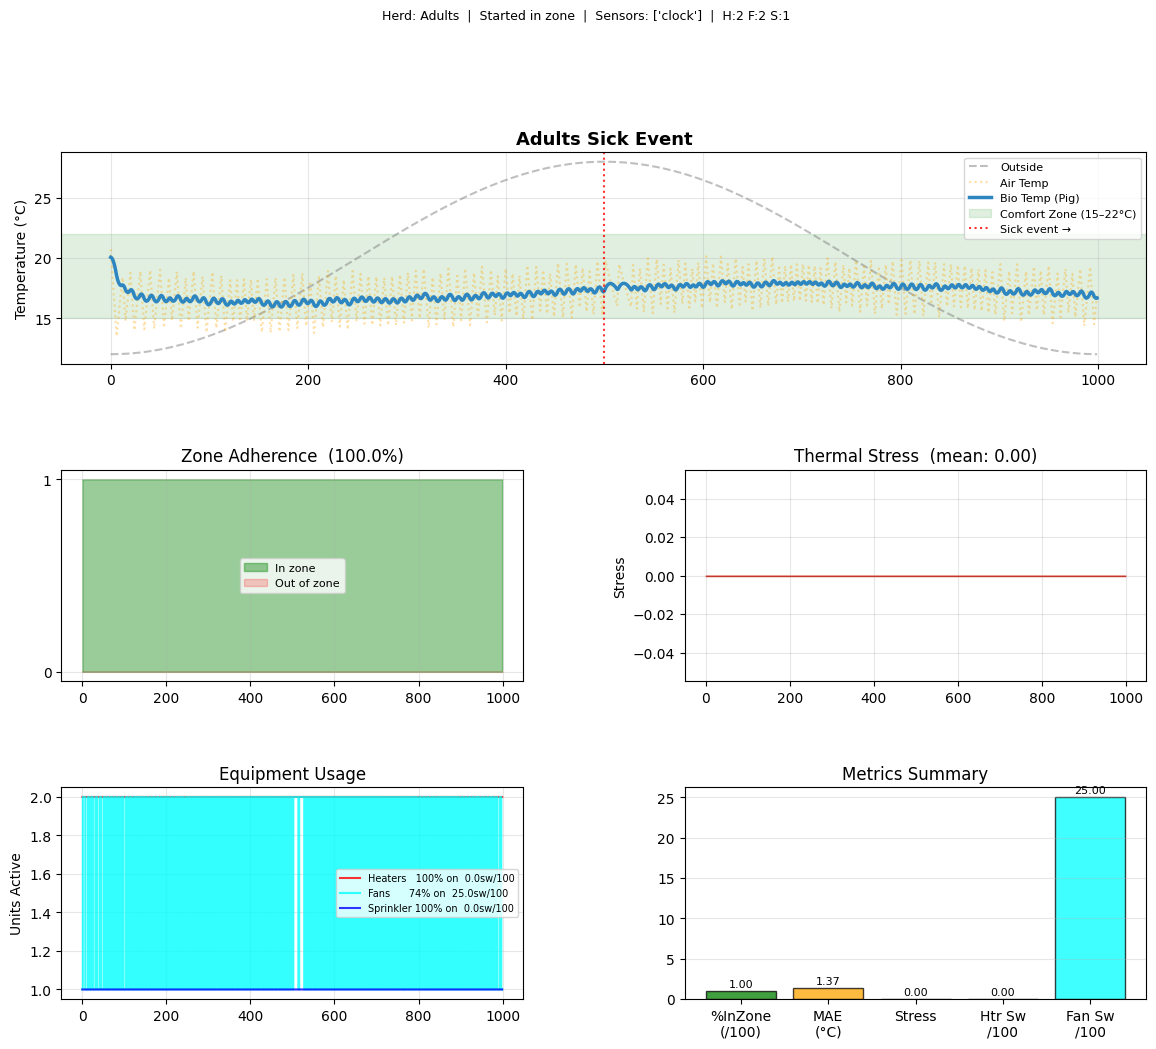

  Plot saved: eval_Adults_Sick_Event.png

  ──────────────────────────────────────────────────────
  Mixed Young Adults
  ──────────────────────────────────────────────────────
  % in comfort zone       :   99.5%
  Mean abs error          :   0.74°C
  Mean thermal stress     :   0.01
  Recovery time           : 5 steps
  Heater   on: 92.7%   switch: 14.3/100 steps
  Fan      on: 51.4%   switch: 33.3/100 steps
  Sprinkler on:100.0%  switch:  0.0/100 steps


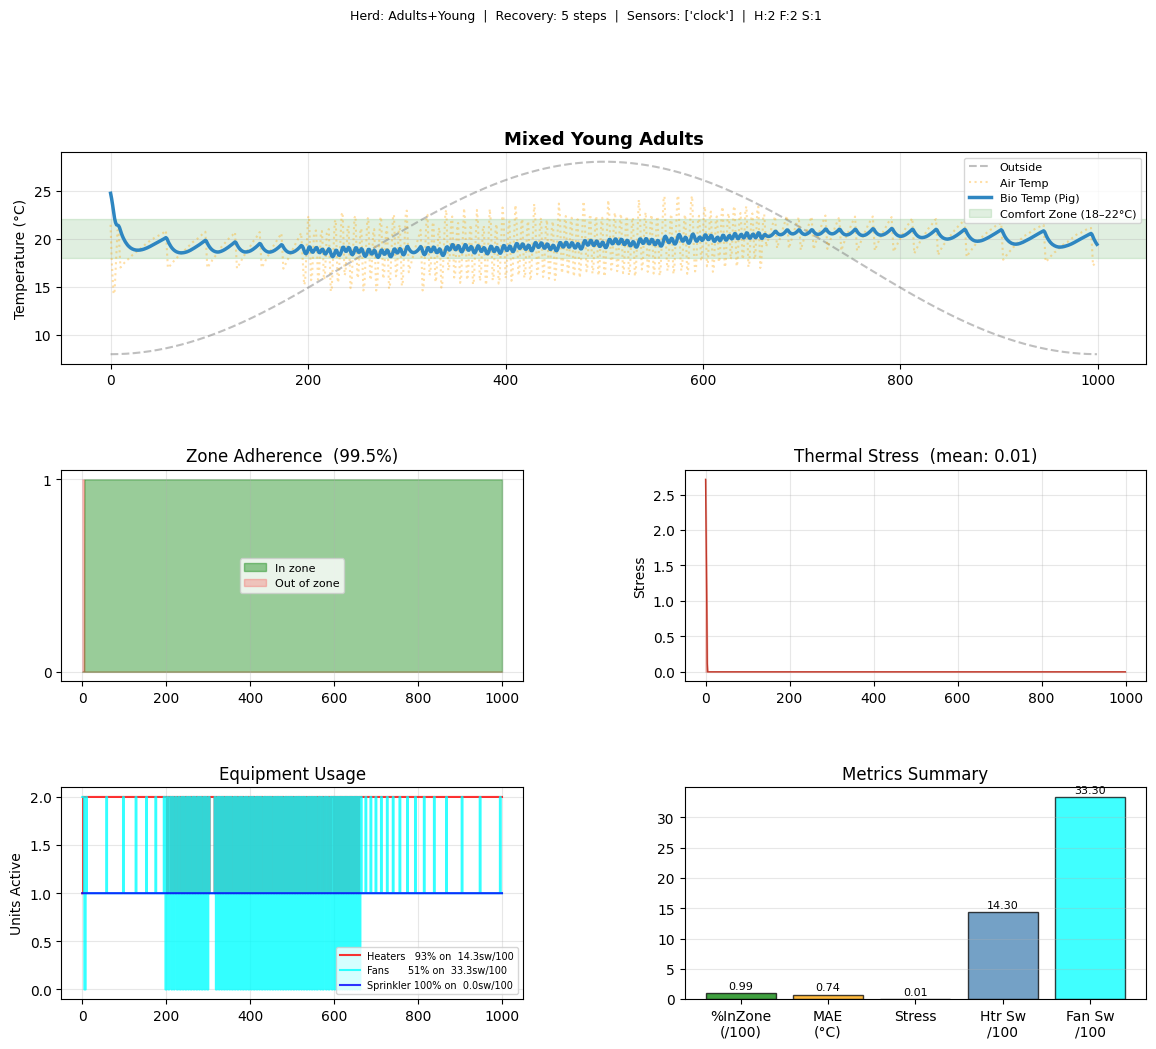

  Plot saved: eval_Mixed_Young_Adults.png

  ──────────────────────────────────────────────────────
  Adults Cold Recovery
  ──────────────────────────────────────────────────────
  % in comfort zone       :   98.3%
  Mean abs error          :   1.34°C
  Mean thermal stress     :   0.17
  Recovery time           : 17 steps
  Heater   on: 99.9%   switch:  0.4/100 steps
  Fan      on: 66.0%   switch: 23.5/100 steps
  Sprinkler on: 99.8%  switch:  0.1/100 steps


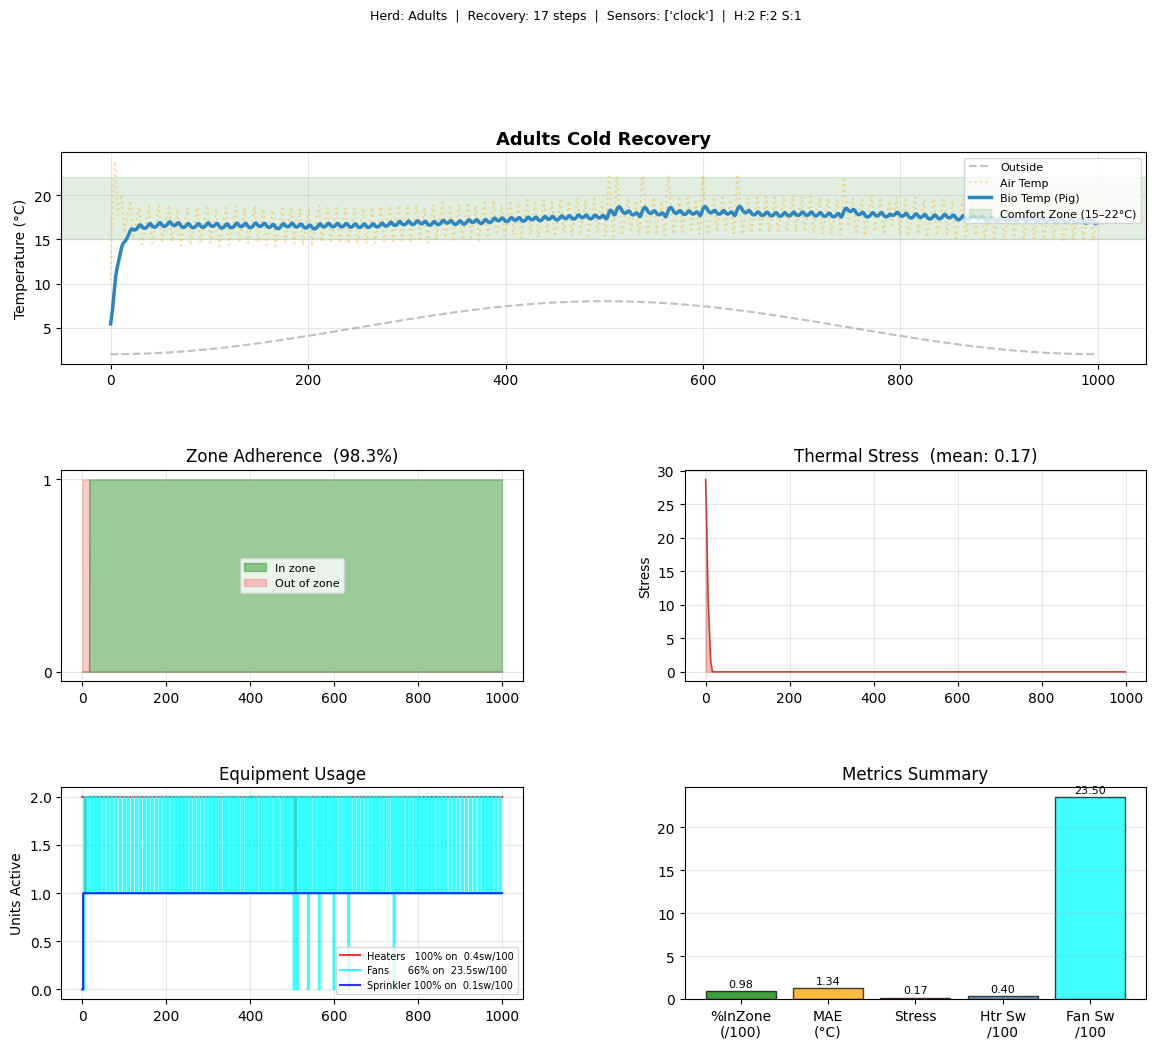

  Plot saved: eval_Adults_Cold_Recovery.png

  ──────────────────────────────────────────────────────
  Piglets Sick Event
  ──────────────────────────────────────────────────────
  % in comfort zone       :   84.9%
  Mean abs error          :   1.62°C
  Mean thermal stress     :   0.37
  Recovery time           : 10 steps
  Heater   on:  0.4%   switch:  0.7/100 steps
  Fan      on:  0.0%   switch:  0.0/100 steps
  Sprinkler on:  4.8%  switch:  9.6/100 steps


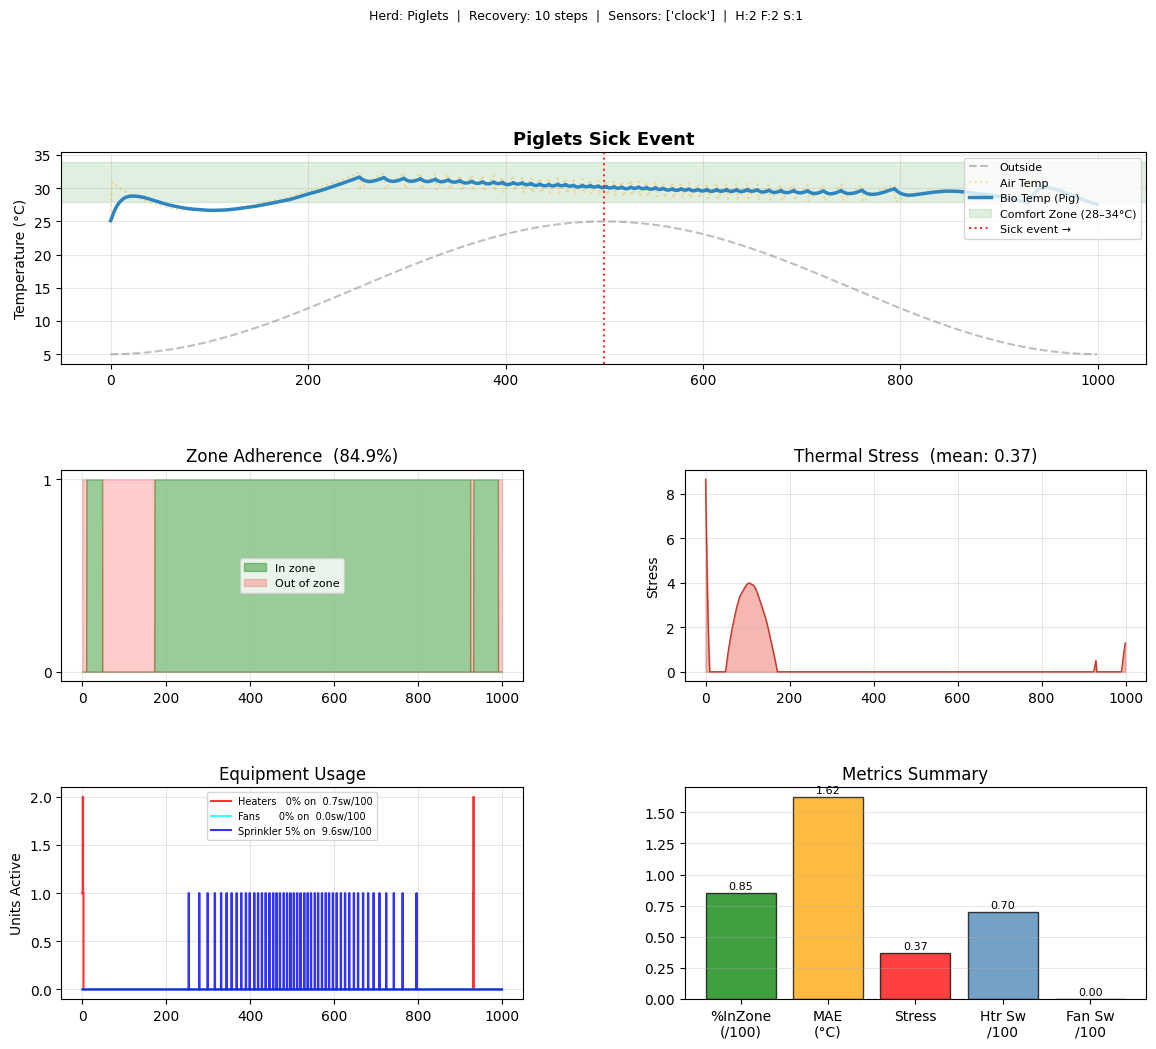

  Plot saved: eval_Piglets_Sick_Event.png

  ──────────────────────────────────────────────────────
  Young Mild Day
  ──────────────────────────────────────────────────────
  % in comfort zone       :  100.0%
  Mean abs error          :   0.77°C
  Mean thermal stress     :   0.00
  Recovery time           : started in zone
  Heater   on: 70.2%   switch: 44.9/100 steps
  Fan      on: 19.4%   switch: 35.0/100 steps
  Sprinkler on:100.0%  switch:  0.0/100 steps


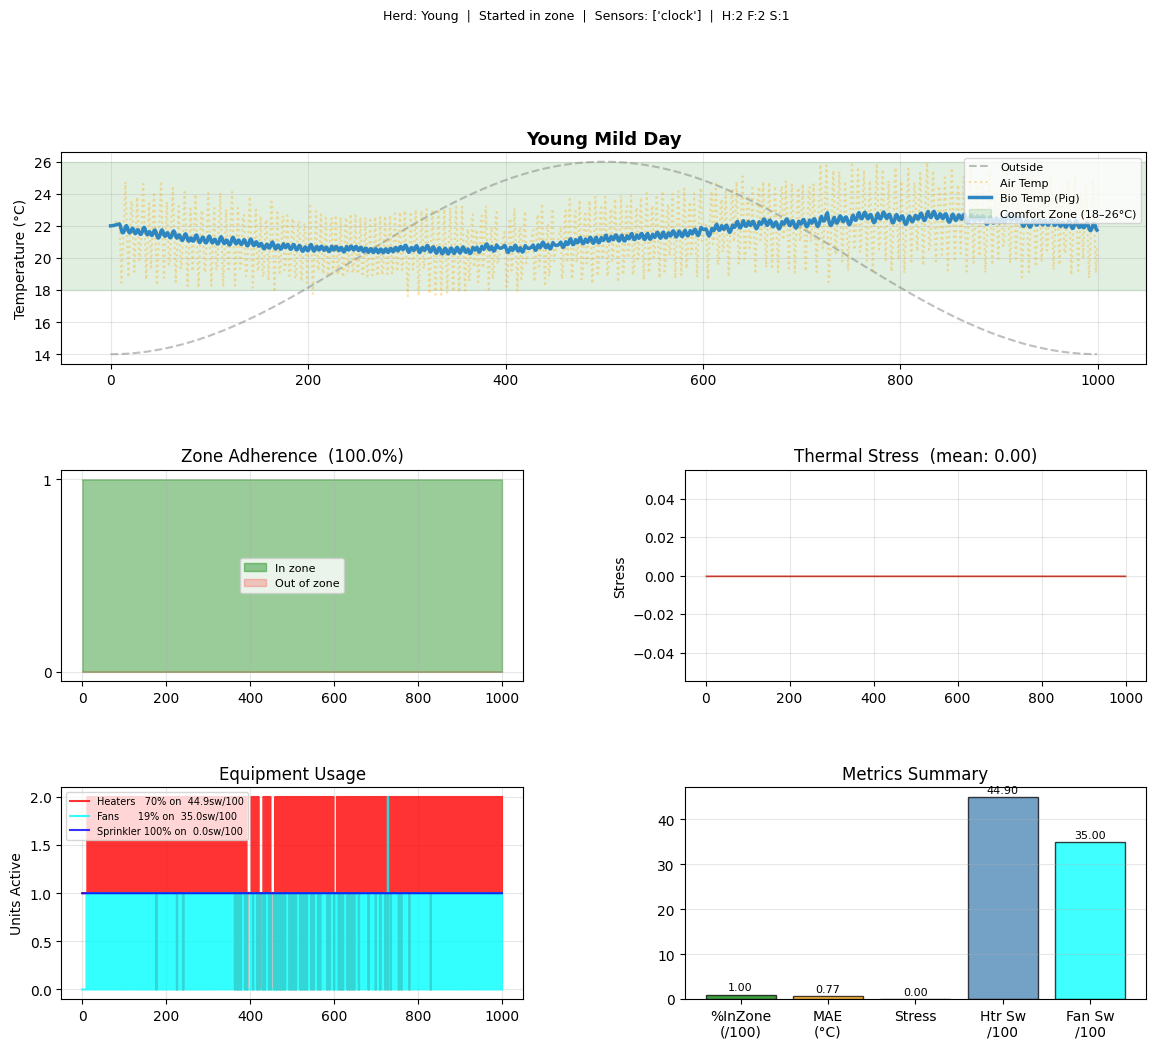

  Plot saved: eval_Young_Mild_Day.png

  ──────────────────────────────────────────────────────
  Diverse Herd
  ──────────────────────────────────────────────────────
  % in comfort zone       :    0.0%
  Mean abs error          :   0.28°C
  Mean thermal stress     :   8.71
  Recovery time           : started in zone
  Heater   on: 57.9%   switch: 51.3/100 steps
  Fan      on: 13.6%   switch: 36.9/100 steps
  Sprinkler on: 99.9%  switch:  0.1/100 steps


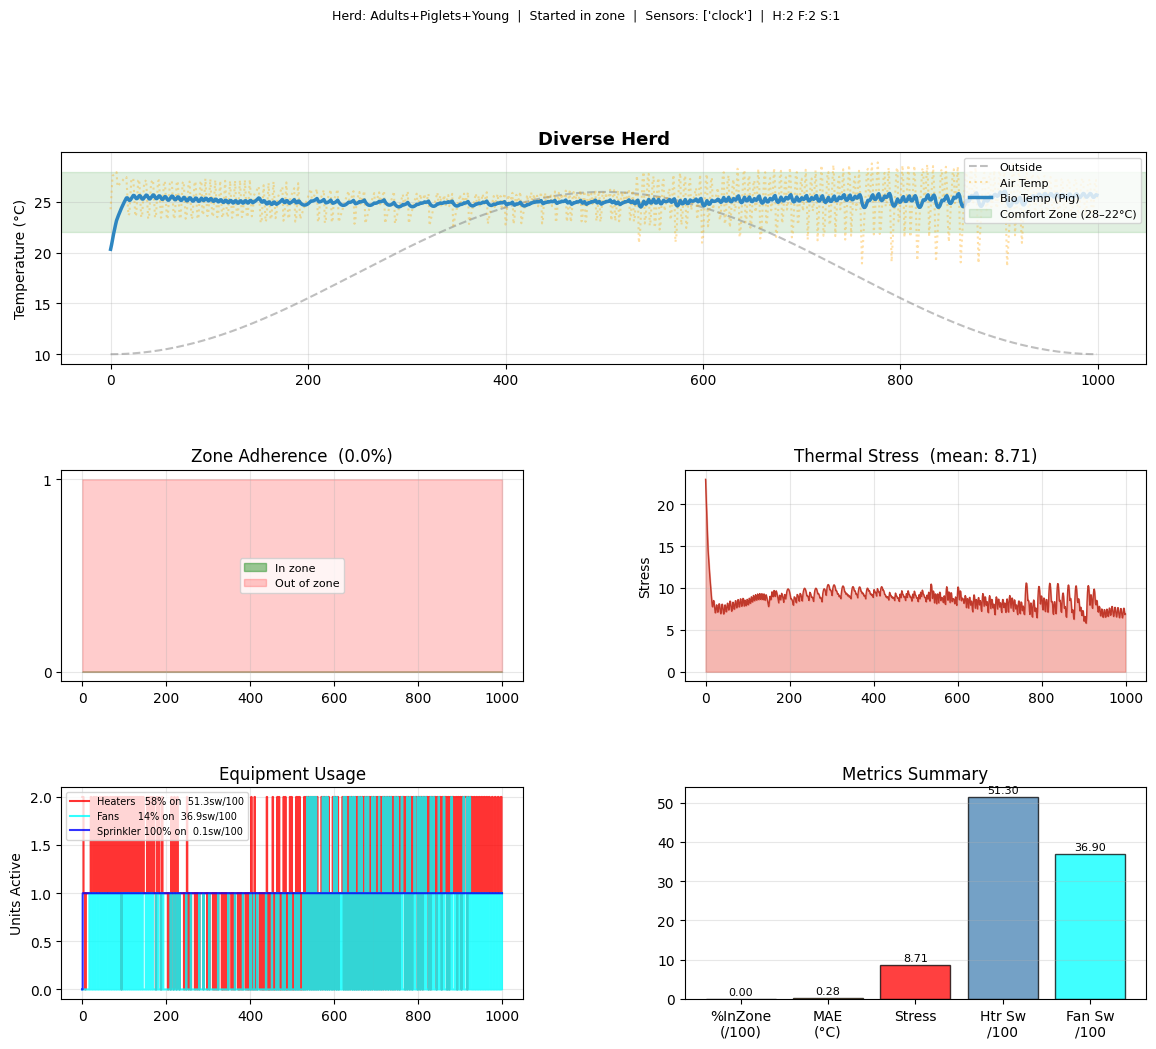

  Plot saved: eval_Diverse_Herd.png

  Cross-Scenario Comparison


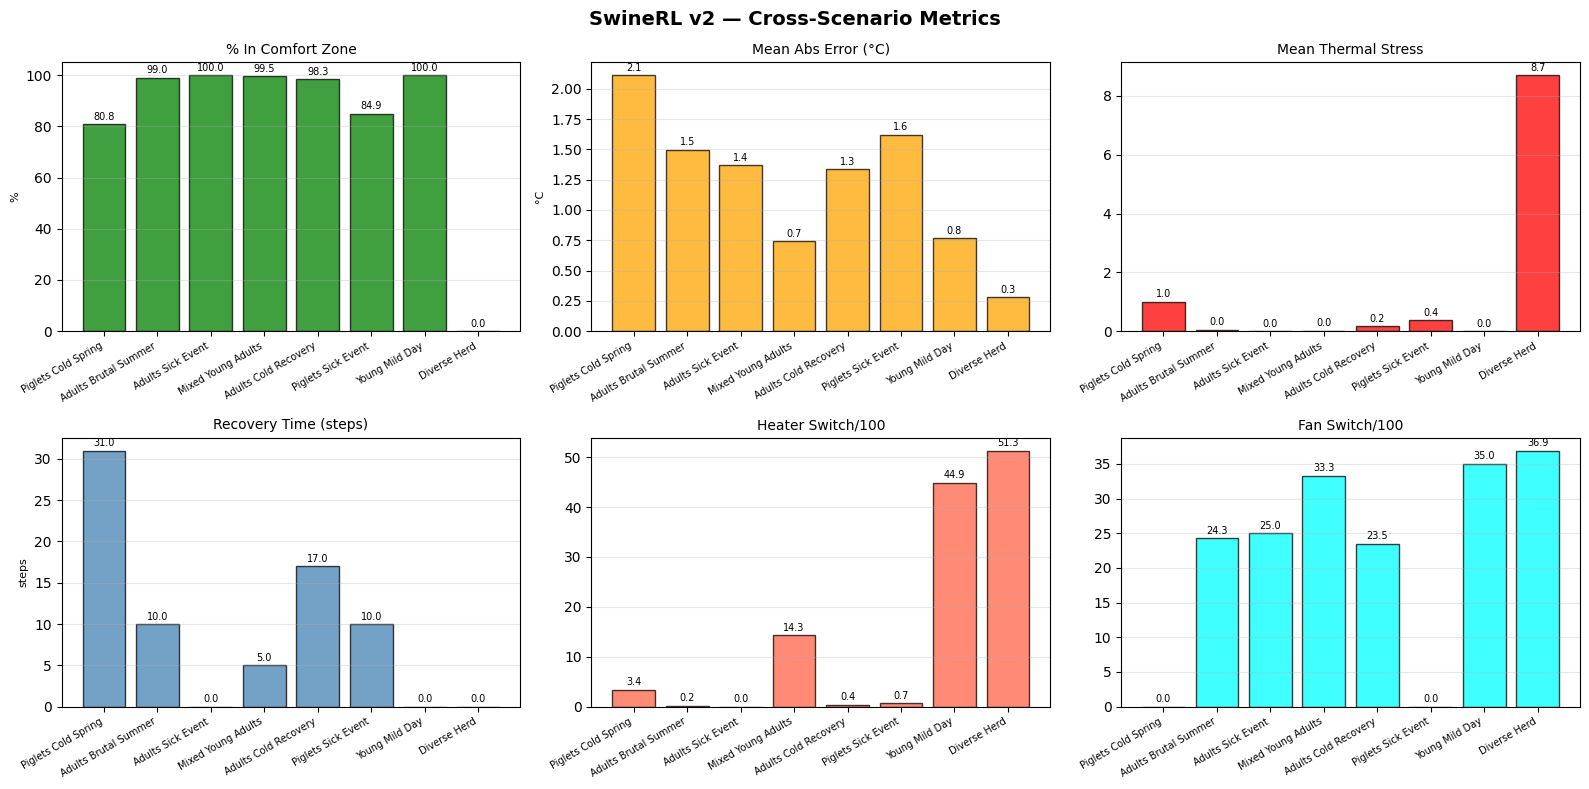

  Comparison saved: eval_comparison.png
  Done.


In [10]:
"""
SwineRL v2 — Evaluation Script
================================
Loads the single trained model and runs it against any sensor/equipment
config specified in config.json ["eval"] section.

Missing sensors → value zeroed + availability flag = 0.0
Missing equipment → action masked to 0 before env receives it

Metrics per scenario:
  - % timesteps inside comfort zone
  - Mean absolute error from zone centre
  - Mean thermal stress
  - Equipment on-rate (heaters, fans, sprinkler)
  - Equipment switching rate (toggles/100 steps) — hardware wear indicator
  - Recovery time from out-of-zone start
  - Cross-scenario comparison plot
"""

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

# ─────────────────────────────────────────────
# 1. LOAD CONFIG
# ─────────────────────────────────────────────
# CONFIG_PATH = "/kaggle/input/datasets/jheelgala/config/config.json"
# with open(CONFIG_PATH, "r") as f:
#     CFG = json.load(f)

HERD_CFG    = CFG["herd"]
EVAL_CFG    = CFG["eval"]
PHYSICS_CFG = CFG["physics"]
TRAIN_CFG   = CFG["training"]

COMFORT = {
    0: HERD_CFG["comfort_zones"]["piglets"],
    1: HERD_CFG["comfort_zones"]["young"],
    2: HERD_CFG["comfort_zones"]["adults"],
}

CFG["eval"]["equipment"]["sprinklers"] = 1

OBS_DIM     = 18
ACTION_NVEC = [2, 2, 2, 2, 2]

print("=" * 60)
print("  SwineRL v2 — Evaluation")
print("=" * 60)
print(f"\n  Eval sensors    : {EVAL_CFG['sensors']}")
print(f"  Eval equipment  : {EVAL_CFG['equipment']}")
print(f"  (Model trained with ALL sensors + equipment on)")


# ─────────────────────────────────────────────
# 2. STUB ENV FOR VECNORMALIZE
# ─────────────────────────────────────────────
class SwineEnvStub(gym.Env):
    """Minimal env — only needed to load VecNormalize stats."""
    def __init__(self):
        super().__init__()
        self.observation_space = spaces.Box(
            low  = np.full(OBS_DIM, -200, dtype=np.float32),
            high = np.full(OBS_DIM,  200, dtype=np.float32),
            dtype=np.float32
        )
        self.action_space = spaces.MultiDiscrete(ACTION_NVEC)
        self.comfort      = COMFORT
        # State variables
        self.air_temp = self.perceived_temp = 25.0
        self.humidity = 55.0
        self.co2      = 800.0
        self.clock_hour = 0.0
        self.heaters  = np.zeros(2, dtype=np.float32)
        self.fans     = np.zeros(2, dtype=np.float32)
        self.sprinkler = 0.0
        self.counts   = [0, 0, 8]
        self.current_herd = [2] * 8
        self.sick_event_active = False

    def reset(self, seed=None, options=None):
        self.air_temp = self.perceived_temp = 25.0
        return self._get_obs(), {}

    def _get_obs(self):
        return np.array([
            self.air_temp, self.perceived_temp,
            self.air_temp - self.perceived_temp,
            self.heaters[0], self.heaters[1],
            self.fans[0],    self.fans[1],
            self.sprinkler,
            float(self.counts[0]), float(self.counts[1]), float(self.counts[2]),
            self.humidity / 100.0,  1.0,
            self.co2 / 5000.0,      1.0,
            np.sin(2 * np.pi * self.clock_hour / 24),
            np.cos(2 * np.pi * self.clock_hour / 24), 1.0,
        ], dtype=np.float32)

    def step(self, action):
        return self._get_obs(), 0.0, False, False, {}


# ─────────────────────────────────────────────
# 3. LOAD MODEL + STATS
# ─────────────────────────────────────────────
eval_env = DummyVecEnv([lambda: SwineEnvStub()])
eval_env = VecNormalize.load("/kaggle/working/swine_vec_normalize_v2_ft.pkl", eval_env)
eval_env.training    = False
eval_env.norm_reward = False
model = PPO.load("/kaggle/working/ppo_swine_v2_ft.zip", device="cpu")


# ─────────────────────────────────────────────
# 4. OBS BUILDER WITH SENSOR MASKING
# ─────────────────────────────────────────────
def build_masked_obs(raw, eval_sensors):
    """
    Builds full 18-dim obs. Unavailable sensors → value=0, flag=0.
    Model learned to ignore flag=0 dimensions during training.
    """
    humidity_val  = raw.humidity / 100.0 if eval_sensors["humidity"] else 0.0
    humidity_flag = 1.0                  if eval_sensors["humidity"] else 0.0
    co2_val       = raw.co2 / 5000.0    if eval_sensors["co2"]      else 0.0
    co2_flag      = 1.0                  if eval_sensors["co2"]      else 0.0

    if eval_sensors["clock"]:
        cs, cc, cf = (np.sin(2*np.pi*raw.clock_hour/24),
                      np.cos(2*np.pi*raw.clock_hour/24), 1.0)
    else:
        cs = cc = cf = 0.0

    return np.array([
        raw.air_temp, raw.perceived_temp,
        raw.air_temp - raw.perceived_temp,
        raw.heaters[0], raw.heaters[1],
        raw.fans[0],    raw.fans[1],
        raw.sprinkler,
        float(raw.counts[0]), float(raw.counts[1]), float(raw.counts[2]),
        humidity_val, humidity_flag,
        co2_val,      co2_flag,
        cs, cc, cf,
    ], dtype=np.float32)


# ─────────────────────────────────────────────
# 5. ACTION MASKER
# ─────────────────────────────────────────────
def mask_action(action, eval_equipment):
    """Forces actions to 0 for equipment not present in eval config."""
    a = action.copy()
    n_heaters    = eval_equipment["heaters"]
    n_fans       = eval_equipment["fans"]
    n_sprinklers = eval_equipment["sprinklers"]
    if n_heaters    < 2: a[0, 1] = 0
    if n_heaters    < 1: a[0, 0] = 0
    if n_fans       < 2: a[0, 3] = 0
    if n_fans       < 1: a[0, 2] = 0
    if n_sprinklers < 1: a[0, 4] = 0
    return a


# ─────────────────────────────────────────────
# 6. METRICS
# ─────────────────────────────────────────────
def compute_metrics(bios, heater_hist, fan_hist, spr_hist, low_zone, high_zone):
    zone_centre = (low_zone + high_zone) / 2.0
    in_zone     = [1 if low_zone <= b <= high_zone else 0 for b in bios]
    pct_in_zone = 100.0 * np.mean(in_zone)
    mae         = np.mean([abs(b - zone_centre) for b in bios])
    stress_hist = [
        (low_zone - b)*3.0 if b < low_zone
        else (b - high_zone) if b > high_zone
        else 0.0
        for b in bios
    ]

    def on_rate(h, max_val=2): return (np.mean(h) / max_val) * 100
    def sw_rate(h):              return 100.0 * np.sum(np.abs(np.diff(h))) / max(len(h),1)

    recovery = next(
        (i for i, b in enumerate(bios) if low_zone <= b <= high_zone),
        None
    ) if (bios[0] < low_zone or bios[0] > high_zone) else None

    return dict(
        pct_in_zone     = pct_in_zone,
        mae             = mae,
        mean_stress     = float(np.mean(stress_hist)),
        heater_on       = on_rate(heater_hist, max_val=2),
        fan_on          = on_rate(fan_hist, max_val=2),
        sprinkler_on    = on_rate(spr_hist, max_val=1),
        heater_switch   = sw_rate(heater_hist),
        fan_switch      = sw_rate(fan_hist),
        sprinkler_switch= sw_rate(spr_hist),
        recovery        = recovery,
        in_zone         = in_zone,
        stress_hist     = stress_hist,
    )


def print_metrics(name, m):
    rt = f"{m['recovery']} steps" if m["recovery"] is not None else "started in zone"
    print(f"\n  {'─'*54}")
    print(f"  {name}")
    print(f"  {'─'*54}")
    print(f"  % in comfort zone       : {m['pct_in_zone']:>6.1f}%")
    print(f"  Mean abs error          : {m['mae']:>6.2f}°C")
    print(f"  Mean thermal stress     : {m['mean_stress']:>6.2f}")
    print(f"  Recovery time           : {rt}")
    print(f"  Heater   on:{m['heater_on']:>5.1f}%   switch:{m['heater_switch']:>5.1f}/100 steps")
    print(f"  Fan      on:{m['fan_on']:>5.1f}%   switch:{m['fan_switch']:>5.1f}/100 steps")
    print(f"  Sprinkler on:{m['sprinkler_on']:>5.1f}%  switch:{m['sprinkler_switch']:>5.1f}/100 steps")


# ─────────────────────────────────────────────
# 7. SCENARIO RUNNER
# ─────────────────────────────────────────────
def run_scenario(name, herd, start_temp, avg_out, amp,
                 has_sick=False, steps=1000, plot=True):
    raw = eval_env.envs[0].unwrapped
    eval_env.reset()

    raw.air_temp        = float(start_temp)
    raw.perceived_temp  = float(start_temp)
    raw.current_herd    = herd
    raw.counts          = [herd.count(i) for i in range(3)]
    raw.clock_hour      = 0.0
    raw.humidity        = 55.0
    raw.co2             = 800.0
    raw.heaters         = np.zeros(2, dtype=np.float32)
    raw.fans            = np.zeros(2, dtype=np.float32)
    raw.sprinkler       = 0.0
    raw.sick_event_active = False

    low_zone  = max([COMFORT[a][0] for a in herd])
    high_zone = min([COMFORT[a][1] for a in herd])

    bios, airs, ambients            = [], [], []
    heater_hist, fan_hist, spr_hist = [], [], []
    sick_flags                      = []

    eval_sensors   = EVAL_CFG["sensors"]
    eval_equipment = EVAL_CFG["equipment"]

    for t in range(steps):
        ambient = avg_out + amp * np.sin(2 * np.pi * t / steps - np.pi / 2)
        raw.air_temp += (ambient - raw.air_temp) * PHYSICS_CFG["ambient_drift_rate"]

        if has_sick and t == steps // 2:
            raw.sick_event_active = True
        if raw.sick_event_active and np.random.rand() > 0.95:
            raw.sick_event_active = False

        raw.clock_hour = (raw.clock_hour + 24.0 / steps) % 24

        obs   = build_masked_obs(raw, eval_sensors)
        obs_n = eval_env.normalize_obs(obs.reshape(1, -1))
        action, _ = model.predict(obs_n, deterministic=True)
        action = mask_action(action, eval_equipment)

        raw.heaters[0] = float(action[0, 0])
        raw.heaters[1] = float(action[0, 1])
        raw.fans[0]    = float(action[0, 2])
        raw.fans[1]    = float(action[0, 3])
        raw.sprinkler  = float(action[0, 4])

        met = PHYSICS_CFG["metabolic_heat"]
        metabolic = (raw.counts[0]*met["piglets"] +
                     raw.counts[1]*met["young"]   +
                     raw.counts[2]*met["adults"])
        if raw.sick_event_active:
            metabolic *= PHYSICS_CFG["sick_metabolic_multiplier"]

        heat_gain = np.sum(raw.heaters) * PHYSICS_CFG["heater_rate"] + metabolic
        cooling   = (np.sum(raw.fans)   * PHYSICS_CFG["fan_rate"] +
                     raw.sprinkler      * PHYSICS_CFG["sprinkler_cooling"])
        raw.air_temp      += heat_gain - cooling + np.random.normal(0, 0.02)
        raw.air_temp       = np.clip(raw.air_temp, 0, 50)
        raw.perceived_temp += (raw.air_temp - raw.perceived_temp) * PHYSICS_CFG["bio_latency"]

        raw.humidity += raw.sprinkler*3.0 - np.sum(raw.fans)*0.5 + np.random.normal(0, 0.3)
        raw.humidity  = np.clip(raw.humidity, 20, 100)
        raw.co2      += len(herd)*2.0 - np.sum(raw.fans)*50.0 + np.random.normal(0, 10)
        raw.co2       = np.clip(raw.co2, 400, 5000)

        bios.append(raw.perceived_temp)
        airs.append(raw.air_temp)
        ambients.append(ambient)
        heater_hist.append(float(np.sum(raw.heaters)))
        fan_hist.append(float(np.sum(raw.fans)))
        spr_hist.append(float(raw.sprinkler))
        sick_flags.append(int(raw.sick_event_active))

    m = compute_metrics(bios, heater_hist, fan_hist, spr_hist, low_zone, high_zone)
    print_metrics(name, m)

    if plot:
        x   = list(range(steps))
        fig = plt.figure(figsize=(14, 11))
        gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.50, wspace=0.35)
        ax1 = fig.add_subplot(gs[0, :])
        ax2 = fig.add_subplot(gs[1, 0])
        ax3 = fig.add_subplot(gs[1, 1])
        ax4 = fig.add_subplot(gs[2, 0])
        ax5 = fig.add_subplot(gs[2, 1])

        ax1.plot(x, ambients, color='gray',    alpha=0.5, linestyle='--', label='Outside')
        ax1.plot(x, airs,     color='orange',  alpha=0.35,linestyle=':',  label='Air Temp')
        ax1.plot(x, bios,     color='#2E86C1', linewidth=2.5,             label='Bio Temp (Pig)')
        ax1.axhspan(low_zone, high_zone, color='green', alpha=0.12,
                    label=f'Comfort Zone ({low_zone}–{high_zone}°C)')
        if has_sick:
            ax1.axvline(steps//2, color='red', linestyle=':', alpha=0.8, label='Sick event →')
        ax1.set_title(name, fontsize=13, fontweight='bold')
        ax1.set_ylabel('Temperature (°C)')
        ax1.legend(loc='upper right', fontsize=8)
        ax1.grid(True, alpha=0.3)

        ax2.fill_between(x, m["in_zone"],           color='green', alpha=0.4, label='In zone')
        ax2.fill_between(x, [1-v for v in m["in_zone"]], color='red', alpha=0.2, label='Out of zone')
        ax2.set_title(f'Zone Adherence  ({m["pct_in_zone"]:.1f}%)')
        ax2.set_yticks([0, 1])
        ax2.legend(fontsize=8)
        ax2.grid(True, alpha=0.3)

        ax3.fill_between(x, m["stress_hist"], color='#E74C3C', alpha=0.4)
        ax3.plot(x, m["stress_hist"], color='#C0392B', linewidth=1)
        ax3.set_title(f'Thermal Stress  (mean: {m["mean_stress"]:.2f})')
        ax3.set_ylabel('Stress')
        ax3.grid(True, alpha=0.3)

        ax4.step(x, heater_hist, where='post', color='red',  alpha=0.8,
                 label=f'Heaters   {m["heater_on"]:.0f}% on  {m["heater_switch"]:.1f}sw/100')
        ax4.step(x, fan_hist,    where='post', color='cyan', alpha=0.8,
                 label=f'Fans      {m["fan_on"]:.0f}% on  {m["fan_switch"]:.1f}sw/100')
        ax4.step(x, spr_hist,    where='post', color='blue', alpha=0.8,
                 label=f'Sprinkler {m["sprinkler_on"]:.0f}% on  {m["sprinkler_switch"]:.1f}sw/100')
        ax4.set_title('Equipment Usage')
        ax4.set_ylabel('Units Active')
        ax4.legend(fontsize=7)
        ax4.grid(True, alpha=0.3)

        labels = ['%InZone\n(/100)', 'MAE\n(°C)', 'Stress', 'Htr Sw\n/100', 'Fan Sw\n/100']
        values = [m['pct_in_zone']/100, m['mae'], m['mean_stress'],
                  m['heater_switch'], m['fan_switch']]
        clrs   = ['green', 'orange', 'red', 'steelblue', 'cyan']
        bars   = ax5.bar(labels, values, color=clrs, alpha=0.75, edgecolor='black')
        for bar, v in zip(bars, values):
            ax5.text(bar.get_x()+bar.get_width()/2,
                     bar.get_height()+max(values)*0.01,
                     f'{v:.2f}', ha='center', va='bottom', fontsize=8)
        ax5.set_title('Metrics Summary')
        ax5.grid(True, alpha=0.3, axis='y')

        age_names  = {0:"Piglets", 1:"Young", 2:"Adults"}
        herd_label = "+".join(sorted(set([age_names[a] for a in herd])))
        rt_str     = f"Recovery: {m['recovery']} steps" if m['recovery'] else "Started in zone"
        active_s   = [k for k,v in eval_sensors.items() if v]
        plt.suptitle(
            f'Herd: {herd_label}  |  {rt_str}  |  '
            f'Sensors: {active_s if active_s else "temp only"}  |  '
            f'H:{eval_equipment["heaters"]} F:{eval_equipment["fans"]} S:{eval_equipment["sprinklers"]}',
            fontsize=9, y=1.01
        )
        fname = f"eval_{name.replace(' ','_')}.png"
        plt.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"  Plot saved: {fname}")

    return m


# ─────────────────────────────────────────────
# 8. RUN SCENARIOS
# ─────────────────────────────────────────────
if __name__ == "__main__":
    all_results = {}

    scenarios = [
        dict(name="Piglets Cold Spring",  herd=[0]*8,             start_temp=10, avg_out=10, amp=8,  has_sick=False),
        dict(name="Adults Brutal Summer", herd=[2]*8,             start_temp=30, avg_out=30, amp=10, has_sick=False),
        dict(name="Adults Sick Event",    herd=[2]*8,             start_temp=20, avg_out=20, amp=8,  has_sick=True),
        dict(name="Mixed Young Adults",   herd=[1,1,1,1,2,2,2,2], start_temp=25, avg_out=18, amp=10, has_sick=False),
        dict(name="Adults Cold Recovery", herd=[2]*8,             start_temp=5,  avg_out=5,  amp=3,  has_sick=False),
        dict(name="Piglets Sick Event",   herd=[0]*8,             start_temp=25, avg_out=15, amp=10, has_sick=True),
        dict(name="Young Mild Day",       herd=[1]*8,             start_temp=22, avg_out=20, amp=6,  has_sick=False),
        dict(name="Diverse Herd",         herd=[0,0,1,1,1,2,2,2], start_temp=20, avg_out=18, amp=8,  has_sick=False),
        
    ]

    for sc in scenarios:
        all_results[sc["name"]] = run_scenario(**sc)

    # ── Cross-scenario comparison ─────────────────────────────────────────
    print("\n" + "="*60)
    print("  Cross-Scenario Comparison")
    print("="*60)

    names    = list(all_results.keys())
    metrics  = {
        "% In Comfort Zone":     ([all_results[n]["pct_in_zone"]       for n in names], "green",     "%"),
        "Mean Abs Error (°C)":   ([all_results[n]["mae"]               for n in names], "orange",    "°C"),
        "Mean Thermal Stress":   ([all_results[n]["mean_stress"]       for n in names], "red",       ""),
        "Recovery Time (steps)": ([all_results[n]["recovery"] or 0     for n in names], "steelblue", "steps"),
        "Heater Switch/100":     ([all_results[n]["heater_switch"]     for n in names], "tomato",    ""),
        "Fan Switch/100":        ([all_results[n]["fan_switch"]        for n in names], "cyan",      ""),
    }

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    fig.suptitle("SwineRL v2 — Cross-Scenario Metrics", fontsize=14, fontweight='bold')

    for ax, (title, (vals, color, unit)) in zip(axes.flat, metrics.items()):
        bars = ax.bar(range(len(names)), vals, color=color, alpha=0.75, edgecolor='black')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+max(vals+[0.001])*0.01,
                    f'{v:.1f}', ha='center', va='bottom', fontsize=7)
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels(names, rotation=30, ha='right', fontsize=7)
        ax.set_title(title, fontsize=10)
        ax.set_ylabel(unit, fontsize=8)
        ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig("eval_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("  Comparison saved: eval_comparison.png")
    print("  Done.")